In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.6 MB/s eta 0:00:00


In [2]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device:", torch.cuda.get_device_name(0))

PyTorch Version: 2.6.0+cu124
CUDA Available: True
GPU Device: Tesla T4


In [3]:
import torch_geometric

print("Torch Geometric:", torch_geometric.__version__)

Torch Geometric: 2.6.1


In [4]:
import torch
import time
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.loader import NeighborLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
from copy import deepcopy
from itertools import combinations

In [5]:
df1 = pd.read_csv("/content/GDSC1.csv", engine='python', on_bad_lines='skip')
df2 = pd.read_csv("/content/GDSC2.csv", engine='python', on_bad_lines='skip')

df1.drop(columns=['log_max_conc_tested','log_max_conc_tested_2'], inplace=True, errors='ignore')
df2.drop(columns=['log_max_conc_tested','log_max_conc_tested_2'], inplace=True, errors='ignore')

df = pd.concat([df1, df2], ignore_index=True)

In [6]:
print(" GDSC1 shape:", df1.shape)
print(" GDSC2 shape:", df2.shape)
print(" Combined shape:", df.shape)

categorical_cols = ['Feature Name', 'Drug name', 'Tissue Type', 'Screening Set']
for col in categorical_cols:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

 GDSC1 shape: (269547, 20)
 GDSC2 shape: (200920, 20)
 Combined shape: (470467, 20)


In [7]:
feature_cols = [
    'n_feature_pos', 'log_ic50_mean_pos', 'log_ic50_mean_neg',
    'feature_pos_ic50_var', 'feature_neg_ic50_var',
    'feature_delta_mean_ic50', 'feature_ic50_t_pval', 'feature_pval',
    'tissue_pval', 'msi_pval'
]
feature_cols = [col for col in feature_cols if col in df.columns]
target_col = 'ic50_effect_size'

df_train, df_val = train_test_split(df, test_size=0.5, random_state=42, shuffle=True)

scaler = StandardScaler()
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_val[feature_cols] = scaler.transform(df_val[feature_cols])

In [8]:
def build_edge_index(df):
    row_idx, col_idx = [], []
    feature_to_indices = df.groupby("Feature Name").indices
    for idx_list in feature_to_indices.values():
        if len(idx_list) < 2:
            continue
        pairs = list(combinations(idx_list, 2))[:500]  # reduce memory
        row_idx += [i for i, j in pairs] + [j for i, j in pairs]
        col_idx += [j for i, j in pairs] + [i for i, j in pairs]
    return torch.tensor([row_idx, col_idx], dtype=torch.long)

def build_data(df):
    x = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y = torch.tensor(df[target_col].values, dtype=torch.float32)
    edge_index = build_edge_index(df)
    return Data(x=x, y=y, edge_index=edge_index)

In [9]:
data_train = build_data(df_train)
data_val = build_data(df_val)

print("Train - Nodes:", data_train.x.size(0), "Features:", data_train.x.size(1))
print("Val   - Nodes:", data_val.x.size(0), "Features:", data_val.x.size(1))
print("Edge index shape:", data_train.edge_index.shape)


Train - Nodes: 235233 Features: 10
Val   - Nodes: 235234 Features: 10
Edge index shape: torch.Size([2, 692000])


In [10]:
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_math_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(False)


Transformer Only

In [11]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [12]:
class TransformerOnlyModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, n_heads=4, n_transformer_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=n_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x = data.x.view(-1, 1, data.num_node_features)
        x = self.input_proj(x)
        x = self.pos_encoder(x)

        x_trans = self.transformer(x).mean(dim=1)
        return self.regressor(x_trans).view(-1)

In [13]:
from torch.optim import Adam
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_train = data_train.to(device)
data_val = data_val.to(device)

model = TransformerOnlyModel(input_dim=data_train.num_node_features).to(device)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

In [14]:
def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        y_pred = model(data).cpu().numpy()
        y_true = data.y.cpu().numpy()
        return {
            "MSE": mean_squared_error(y_true, y_pred),
            "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)
        }

results={}
model_name="Transformer Model"
train_losses = []
val_r2s = []
val_maes = []
val_mses = []

epochs = 100
best_r2 = float("-inf")
best_model_state = None

print("📦 Starting training for Transformer....")
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    pred = model(data_train)
    loss = criterion(pred, data_train.y)
    loss.backward()
    optimizer.step()

    val_scores = evaluate(model, data_val)
    train_losses.append(loss.item())
    val_r2s.append(val_scores["R2"])
    val_maes.append(val_scores["MAE"])
    val_mses.append(val_scores["MSE"])

    if val_scores["R2"] > best_r2:
        best_r2 = val_scores["R2"]
        best_model_state = model.state_dict()

    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch:03d}] Train Loss: {loss.item():.4f} | Val MSE: {val_scores['MSE']:.4f} | Val MAE: {val_scores['MAE']:.4f} | Val R2: {val_scores['R2']:.4f}")

model.load_state_dict(best_model_state)
print(f"✅ Training complete. Best R2: {best_r2:.4f}")

results[model_name] = {
    "model": deepcopy(model),
    "R2": best_r2,
    "MSE": val_mses[-1],
    "MAE": val_maes[-1]
}


📦 Starting training for Transformer....
[Epoch 001] Train Loss: 0.1821 | Val MSE: 0.3060 | Val MAE: 0.5194 | Val R2: -5.6914
[Epoch 005] Train Loss: 0.0839 | Val MSE: 0.0491 | Val MAE: 0.1406 | Val R2: -0.0729
[Epoch 010] Train Loss: 0.0499 | Val MSE: 0.0440 | Val MAE: 0.1768 | Val R2: 0.0379
[Epoch 015] Train Loss: 0.0338 | Val MSE: 0.0334 | Val MAE: 0.1071 | Val R2: 0.2703
[Epoch 020] Train Loss: 0.0221 | Val MSE: 0.0219 | Val MAE: 0.1079 | Val R2: 0.5219
[Epoch 025] Train Loss: 0.0191 | Val MSE: 0.0189 | Val MAE: 0.0954 | Val R2: 0.5878
[Epoch 030] Train Loss: 0.0166 | Val MSE: 0.0149 | Val MAE: 0.0838 | Val R2: 0.6745
[Epoch 035] Train Loss: 0.0136 | Val MSE: 0.0111 | Val MAE: 0.0657 | Val R2: 0.7570
[Epoch 040] Train Loss: 0.0111 | Val MSE: 0.0086 | Val MAE: 0.0557 | Val R2: 0.8113
[Epoch 045] Train Loss: 0.0089 | Val MSE: 0.0073 | Val MAE: 0.0544 | Val R2: 0.8402
[Epoch 050] Train Loss: 0.0072 | Val MSE: 0.0057 | Val MAE: 0.0475 | Val R2: 0.8752
[Epoch 055] Train Loss: 0.0061 | V

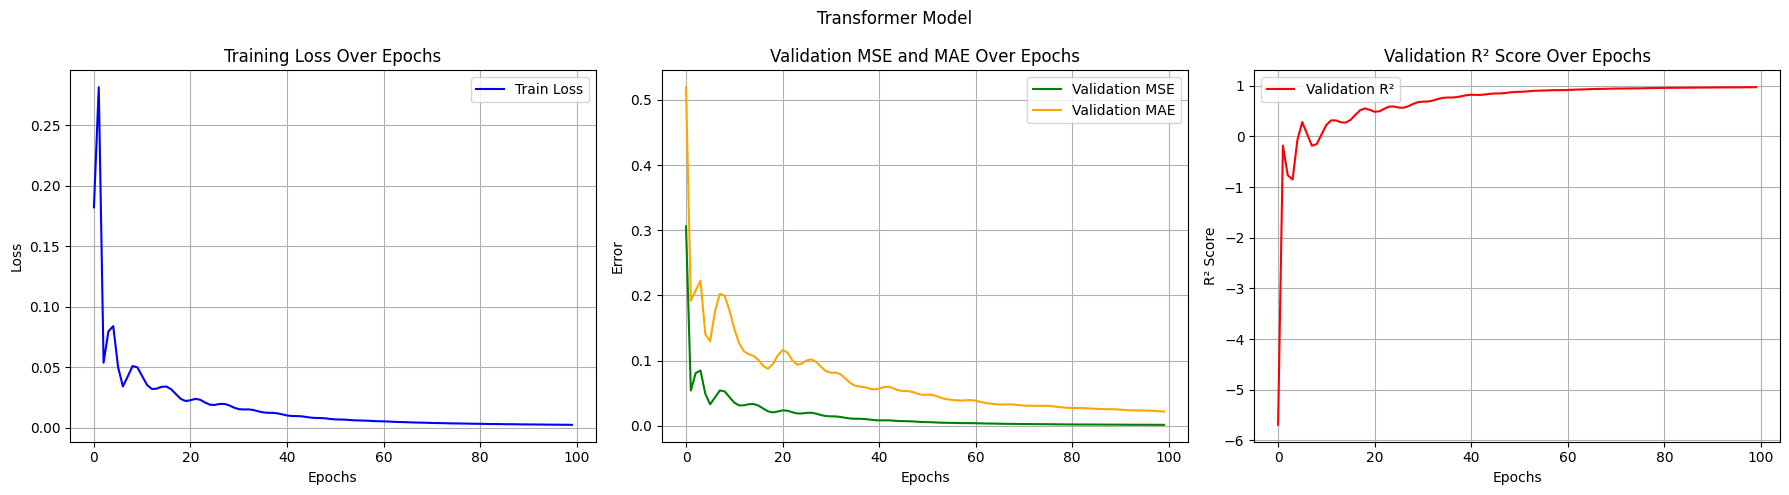

In [15]:
import matplotlib.pyplot as plt

model.load_state_dict(best_model_state)
model.eval()

plt.figure(figsize=(18, 5))
plt.suptitle("Transformer Model")
# Training Loss
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.legend()

# MAE and MSE
plt.subplot(1, 3, 2)
plt.plot(val_mses, label='Validation MSE', color='green')
plt.plot(val_maes, label='Validation MAE', color='orange')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Validation MSE and MAE Over Epochs")
plt.grid(True)
plt.legend()

# R²
plt.subplot(1, 3, 3)
plt.plot(val_r2s, label='Validation R²', color='red')
plt.xlabel("Epochs")
plt.ylabel("R² Score")
plt.title("Validation R² Score Over Epochs")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Transformer Model Evaluation


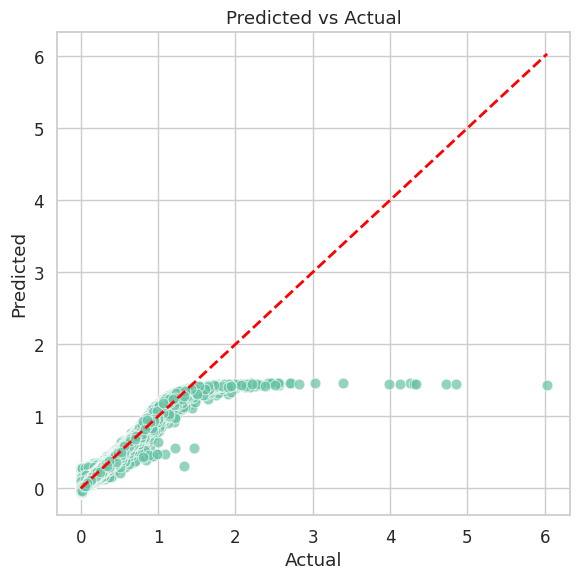

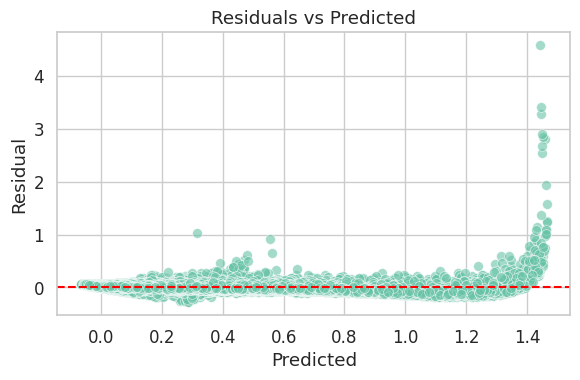

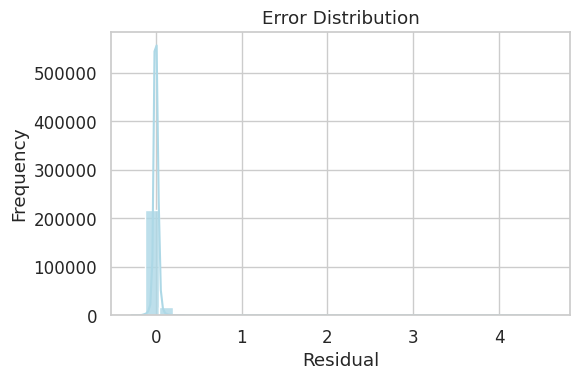

In [16]:
import seaborn as sns
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

# 🎯 Get predictions
model.eval()
with torch.no_grad():
    y_pred = model(data_val).cpu().numpy()
    y_true = data_val.y.cpu().numpy()
    residuals = y_true - y_pred
print("Transformer Model Evaluation")
# ➤ 1. Predicted vs Actual
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_true, y=y_pred, s=60, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.show()

# ➤ 2. Residuals vs Predicted
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, s=50, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

# ➤ 3. Error Distribution
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, kde=True, color='lightblue', edgecolor=None, alpha=0.8)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.tight_layout()
plt.show()

In [17]:
# Calculate the average of last N epochs
N = 10  # You can change this to 5 or 20

avg_train_loss = sum(train_losses[-N:]) / N
avg_val_mse = sum(val_mses[-N:]) / N

print(f"\n📊 Last {N} Epochs Average:")
print(f"  ➤ Train Loss: {avg_train_loss:.4f}")
print(f"  ➤ Validation MSE: {avg_val_mse:.4f}")

# Simple overfitting check
if avg_train_loss < avg_val_mse * 0.7:
    print("⚠️ Possible Overfitting: Training loss is much lower than validation loss.")
elif avg_val_mse < avg_train_loss:
    print("✅ Good: Validation error is even lower than training (unlikely, but good).")
else:
    print("👍 Balanced: No strong signs of overfitting.")


📊 Last 10 Epochs Average:
  ➤ Train Loss: 0.0026
  ➤ Validation MSE: 0.0016
✅ Good: Validation error is even lower than training (unlikely, but good).


BiLSTM Only

In [18]:
class BiLSTMOnlyModel(nn.Module):
    def __init__(self, input_dim, lstm_hidden_dim=32, lstm_layers=1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, lstm_hidden_dim * 2)

        self.bilstm = nn.LSTM(
            input_size=lstm_hidden_dim * 2,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True
        )

        self.regressor = nn.Sequential(
            nn.Linear(2 * lstm_hidden_dim, lstm_hidden_dim),
            nn.ReLU(),
            nn.Linear(lstm_hidden_dim, 1)
        )

    def forward(self, data):
        x = data.x.view(-1, 1, data.num_node_features)  # [N, 1, input_dim]
        x = self.input_proj(x)                          # [N, 1, 2*lstm_hidden]
        lstm_out, _ = self.bilstm(x)                    # [N, 1, 2*lstm_hidden]
        x_pooled = lstm_out.mean(dim=1)                 # [N, 2*lstm_hidden]
        return self.regressor(x_pooled).view(-1)



In [19]:
from torch.optim import Adam
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_train = data_train.to(device)
data_val = data_val.to(device)

model = BiLSTMOnlyModel(input_dim=data_train.num_node_features).to(device)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

In [20]:
def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        y_pred = model(data).cpu().numpy()
        y_true = data.y.cpu().numpy()
        return {
            "MSE": mean_squared_error(y_true, y_pred),
            "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)
        }

model_name="BiLSTM Model"
train_losses = []
val_r2s = []
val_maes = []
val_mses = []

epochs = 100
best_r2 = float("-inf")
best_model_state = None

print("📦 Starting training for BiLSTM...")
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    pred = model(data_train)
    loss = criterion(pred, data_train.y)
    loss.backward()
    optimizer.step()

    val_scores = evaluate(model, data_val)
    train_losses.append(loss.item())
    val_r2s.append(val_scores["R2"])
    val_maes.append(val_scores["MAE"])
    val_mses.append(val_scores["MSE"])

    if val_scores["R2"] > best_r2:
        best_r2 = val_scores["R2"]
        best_model_state = model.state_dict()

    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch:03d}] Train Loss: {loss.item():.4f} | Val MSE: {val_scores['MSE']:.4f} | Val MAE: {val_scores['MAE']:.4f} | Val R2: {val_scores['R2']:.4f}")

model.load_state_dict(best_model_state)
print(f"✅ Training complete. Best R2: {best_r2:.4f}")

results[model_name] = {
    "model": deepcopy(model),
    "R2": best_r2,
    "MSE": val_mses[-1],
    "MAE": val_maes[-1]
}


📦 Starting training for BiLSTM...
[Epoch 001] Train Loss: 0.0702 | Val MSE: 0.0664 | Val MAE: 0.1738 | Val R2: -0.4515
[Epoch 005] Train Loss: 0.0540 | Val MSE: 0.0508 | Val MAE: 0.1469 | Val R2: -0.1115
[Epoch 010] Train Loss: 0.0375 | Val MSE: 0.0352 | Val MAE: 0.1189 | Val R2: 0.2293
[Epoch 015] Train Loss: 0.0263 | Val MSE: 0.0254 | Val MAE: 0.1041 | Val R2: 0.4455
[Epoch 020] Train Loss: 0.0220 | Val MSE: 0.0221 | Val MAE: 0.1044 | Val R2: 0.5166
[Epoch 025] Train Loss: 0.0192 | Val MSE: 0.0188 | Val MAE: 0.0926 | Val R2: 0.5899
[Epoch 030] Train Loss: 0.0152 | Val MSE: 0.0150 | Val MAE: 0.0779 | Val R2: 0.6728
[Epoch 035] Train Loss: 0.0128 | Val MSE: 0.0128 | Val MAE: 0.0699 | Val R2: 0.7204
[Epoch 040] Train Loss: 0.0109 | Val MSE: 0.0109 | Val MAE: 0.0645 | Val R2: 0.7618
[Epoch 045] Train Loss: 0.0092 | Val MSE: 0.0091 | Val MAE: 0.0597 | Val R2: 0.8008
[Epoch 050] Train Loss: 0.0075 | Val MSE: 0.0075 | Val MAE: 0.0534 | Val R2: 0.8354
[Epoch 055] Train Loss: 0.0063 | Val MSE

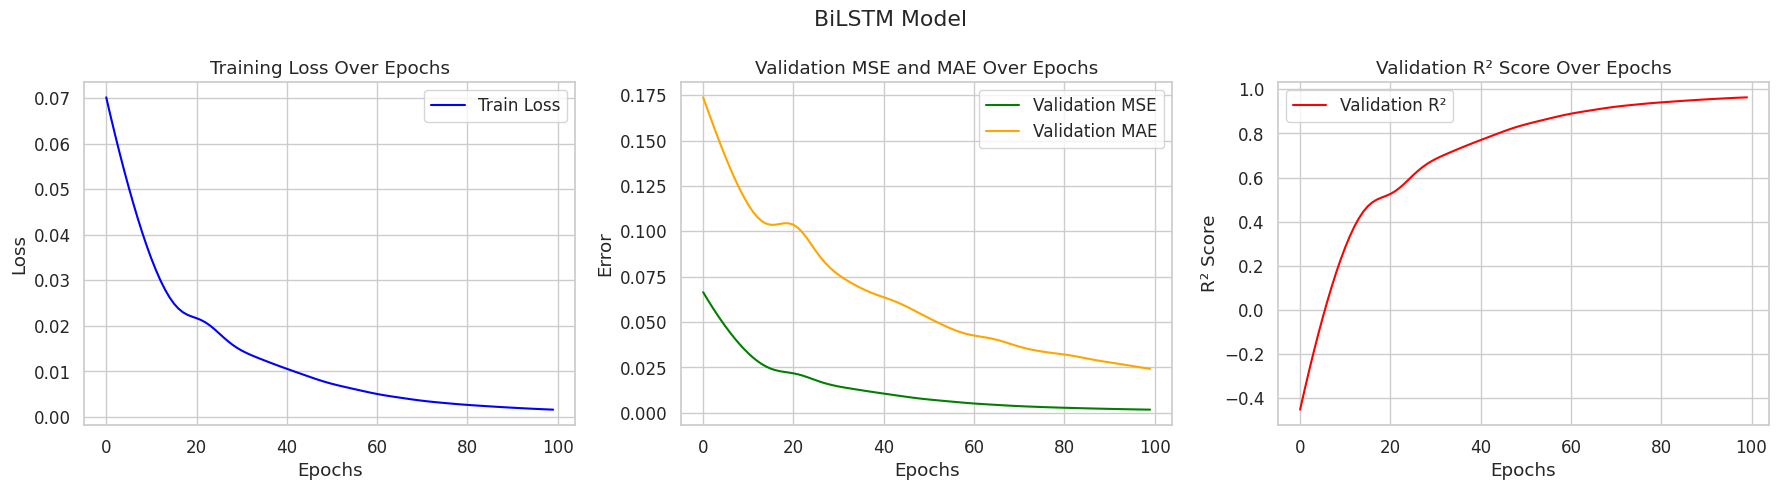

In [21]:
model.load_state_dict(best_model_state)
model.eval()

plt.figure(figsize=(18, 5))
plt.suptitle("BiLSTM Model")
# Training Loss
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.legend()

# MAE and MSE
plt.subplot(1, 3, 2)
plt.plot(val_mses, label='Validation MSE', color='green')
plt.plot(val_maes, label='Validation MAE', color='orange')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Validation MSE and MAE Over Epochs")
plt.grid(True)
plt.legend()

# R²
plt.subplot(1, 3, 3)
plt.plot(val_r2s, label='Validation R²', color='red')
plt.xlabel("Epochs")
plt.ylabel("R² Score")
plt.title("Validation R² Score Over Epochs")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

BiLSTM Model Evaluation


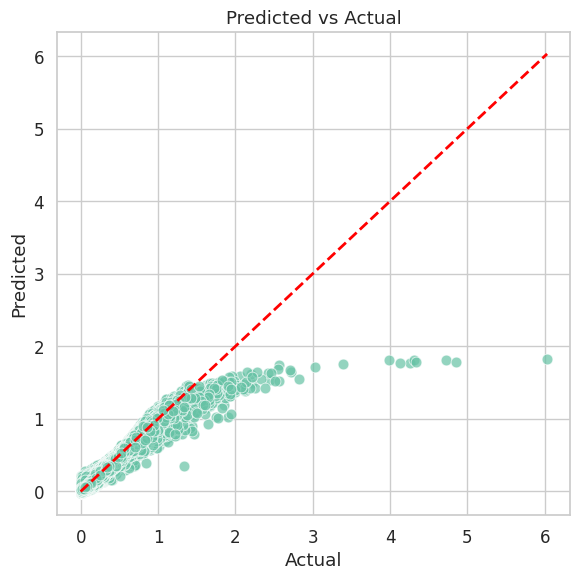

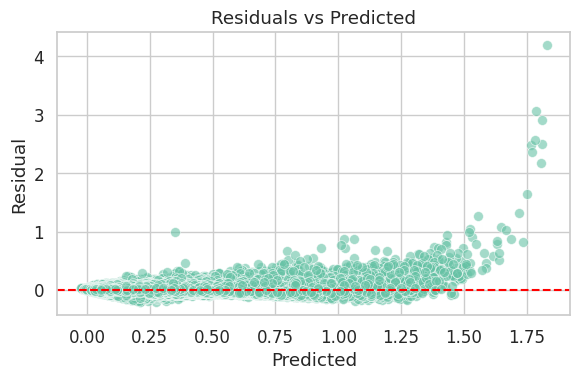

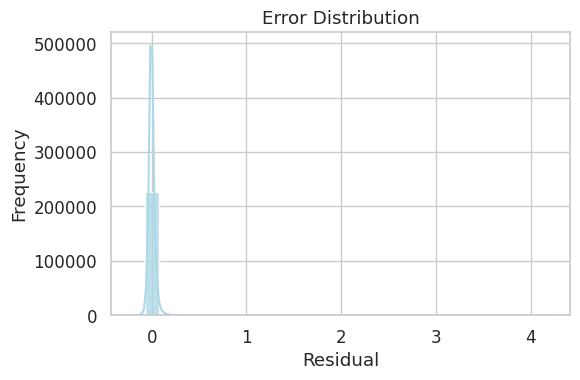

In [22]:
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

# 🎯 Get predictions
model.eval()
with torch.no_grad():
    y_pred = model(data_val).cpu().numpy()
    y_true = data_val.y.cpu().numpy()
    residuals = y_true - y_pred
print("BiLSTM Model Evaluation")
# ➤ 1. Predicted vs Actual
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_true, y=y_pred, s=60, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.show()

# ➤ 2. Residuals vs Predicted
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, s=50, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

# ➤ 3. Error Distribution
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, kde=True, color='lightblue', edgecolor=None, alpha=0.8)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.tight_layout()
plt.show()

In [23]:
# Calculate the average of last N epochs
N = 10  # You can change this to 5 or 20

avg_train_loss = sum(train_losses[-N:]) / N
avg_val_mse = sum(val_mses[-N:]) / N

print(f"\n📊 Last {N} Epochs Average:")
print(f"  ➤ Train Loss: {avg_train_loss:.4f}")
print(f"  ➤ Validation MSE: {avg_val_mse:.4f}")

# Simple overfitting check
if avg_train_loss < avg_val_mse * 0.7:
    print("⚠️ Possible Overfitting: Training loss is much lower than validation loss.")
elif avg_val_mse < avg_train_loss:
    print("✅ Good: Validation error is even lower than training (unlikely, but good).")
else:
    print("👍 Balanced: No strong signs of overfitting.")


📊 Last 10 Epochs Average:
  ➤ Train Loss: 0.0018
  ➤ Validation MSE: 0.0019
👍 Balanced: No strong signs of overfitting.


Transformer + BiLSTM

In [24]:
# Final Model (Transformer + BiLSTM)
class TransformerBiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, n_heads=4, n_transformer_layers=2, lstm_hidden_dim=32, lstm_layers=1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.pos_encoder = PositionalEncoding(hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=n_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)

        self.bilstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True
        )

        total_dim = hidden_dim + 2 * lstm_hidden_dim
        self.regressor = nn.Sequential(
            nn.Linear(total_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        # Reshape input to [batch_size, sequence_len, input_dim]
        x = data.x.view(-1, 1, data.num_node_features)  # shape: [N, 1, 10]
        x = self.input_proj(x)  # [N, 1, hidden_dim]
        x = self.pos_encoder(x)

        # Transformer
        x_trans = self.transformer(x).mean(dim=1)  # [N, hidden_dim]

        # BiLSTM
        lstm_out, _ = self.bilstm(x)
        x_lstm = lstm_out.mean(dim=1)  # [N, 2 * lstm_hidden_dim]

        # Concatenate
        combined = torch.cat([x_trans, x_lstm], dim=1)
        return self.regressor(combined).view(-1)

In [25]:
from torch.optim import Adam
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_train = data_train.to(device)
data_val = data_val.to(device)

model = TransformerBiLSTMModel(input_dim=data_train.num_node_features).to(device)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()


In [26]:
def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        y_pred = model(data).cpu().numpy()
        y_true = data.y.cpu().numpy()
        return {
            "MSE": mean_squared_error(y_true, y_pred),
            "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)
        }

model_name="Transformer+BiLSTM Model"
train_losses=[]
val_r2s=[]
val_maes = []
val_mses = []
# Training loop
epochs = 100
best_r2 = float("-inf")
best_model_state = None

print("📦 Starting training for Transformer+BiLSTM...")
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    pred = model(data_train)
    loss = criterion(pred, data_train.y)
    loss.backward()
    optimizer.step()

    val_scores = evaluate(model, data_val)
    train_losses.append(loss.item())
    val_r2s.append(val_scores["R2"])
    val_maes.append(val_scores["MAE"])
    val_mses.append(val_scores["MSE"])

    if val_scores["R2"] > best_r2:
        best_r2 = val_scores["R2"]
        best_model_state = model.state_dict()

    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch:03d}] Train Loss: {loss.item():.4f} | Val MSE: {val_scores['MSE']:.4f} | Val MAE: {val_scores['MAE']:.4f} | Val R2: {val_scores['R2']:.4f}")

# Load best model
model.load_state_dict(best_model_state)
print(f"✅ Training complete. Best R2: {best_r2:.4f}")

results[model_name] = {
    "model": deepcopy(model),
    "R2": best_r2,
    "MSE": val_mses[-1],
    "MAE": val_maes[-1]
}

📦 Starting training for Transformer+BiLSTM...
[Epoch 001] Train Loss: 0.0987 | Val MSE: 0.2212 | Val MAE: 0.4411 | Val R2: -3.8374
[Epoch 005] Train Loss: 0.0677 | Val MSE: 0.0452 | Val MAE: 0.1302 | Val R2: 0.0125
[Epoch 010] Train Loss: 0.0400 | Val MSE: 0.0368 | Val MAE: 0.1595 | Val R2: 0.1954
[Epoch 015] Train Loss: 0.0279 | Val MSE: 0.0271 | Val MAE: 0.0989 | Val R2: 0.4075
[Epoch 020] Train Loss: 0.0202 | Val MSE: 0.0200 | Val MAE: 0.1013 | Val R2: 0.5619
[Epoch 025] Train Loss: 0.0174 | Val MSE: 0.0161 | Val MAE: 0.0880 | Val R2: 0.6482
[Epoch 030] Train Loss: 0.0140 | Val MSE: 0.0121 | Val MAE: 0.0746 | Val R2: 0.7346
[Epoch 035] Train Loss: 0.0108 | Val MSE: 0.0088 | Val MAE: 0.0600 | Val R2: 0.8067
[Epoch 040] Train Loss: 0.0079 | Val MSE: 0.0064 | Val MAE: 0.0483 | Val R2: 0.8596
[Epoch 045] Train Loss: 0.0061 | Val MSE: 0.0051 | Val MAE: 0.0422 | Val R2: 0.8887
[Epoch 050] Train Loss: 0.0049 | Val MSE: 0.0040 | Val MAE: 0.0385 | Val R2: 0.9133
[Epoch 055] Train Loss: 0.004

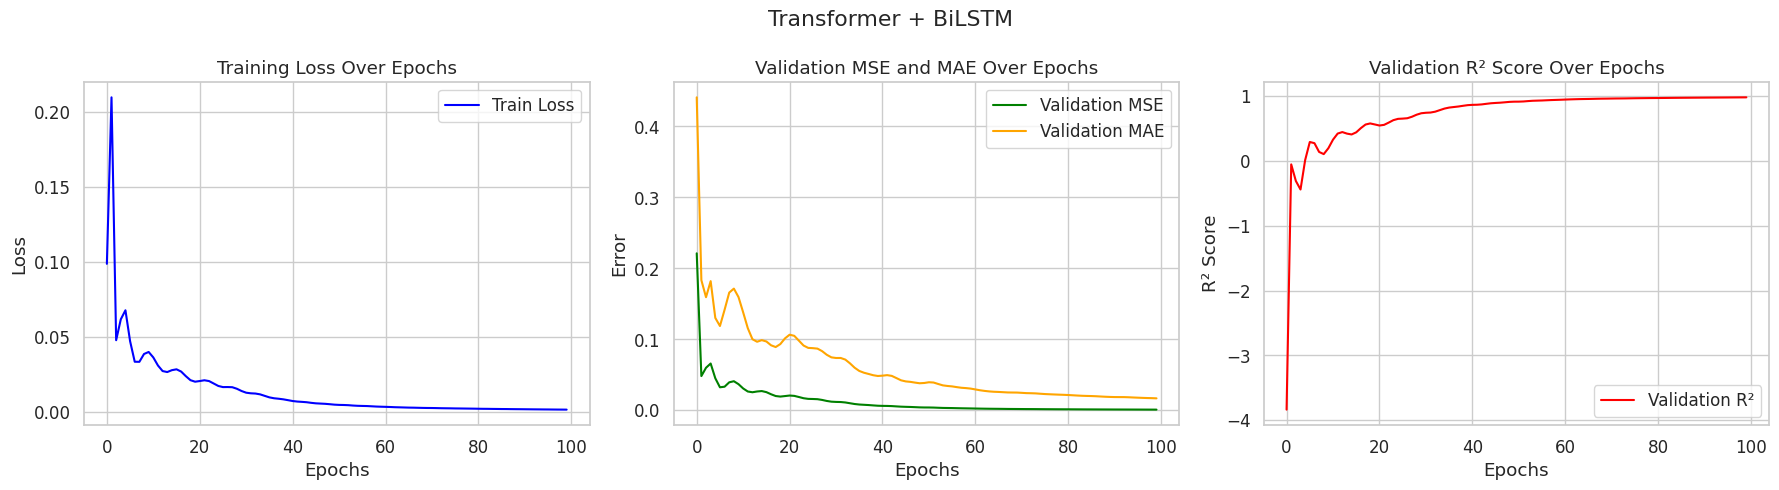

In [27]:
import matplotlib.pyplot as plt

model.load_state_dict(best_model_state)
model.eval()

plt.figure(figsize=(18, 5))
plt.suptitle("Transformer + BiLSTM")
# Training Loss
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.legend()

# MAE and MSE
plt.subplot(1, 3, 2)
plt.plot(val_mses, label='Validation MSE', color='green')
plt.plot(val_maes, label='Validation MAE', color='orange')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Validation MSE and MAE Over Epochs")
plt.grid(True)
plt.legend()

# R²
plt.subplot(1, 3, 3)
plt.plot(val_r2s, label='Validation R²', color='red')
plt.xlabel("Epochs")
plt.ylabel("R² Score")
plt.title("Validation R² Score Over Epochs")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Transformer + BiLSTM Model Evaluation


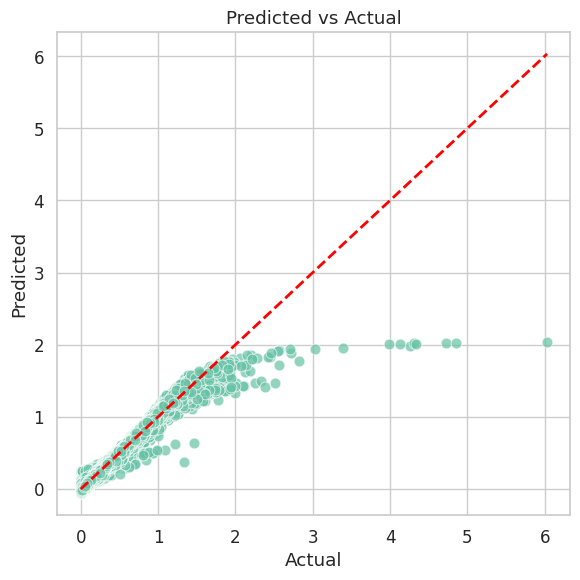

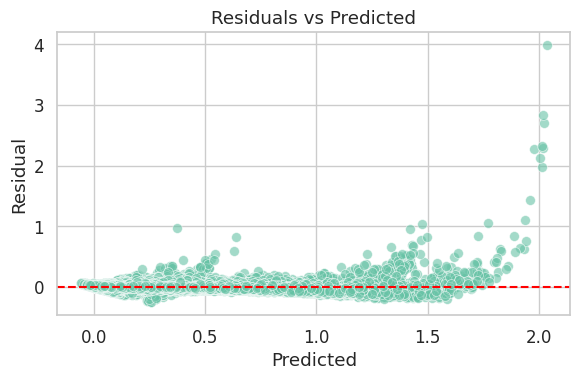

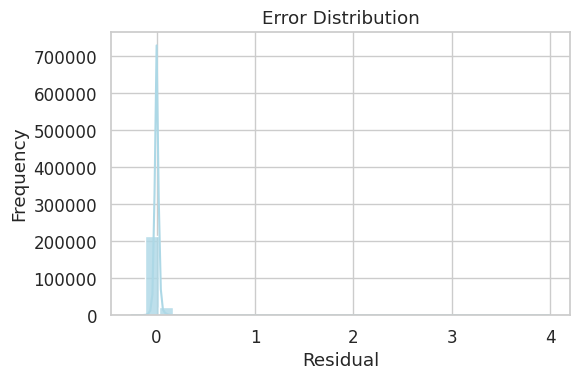

In [28]:
# 🎯 Get predictions
model.eval()
with torch.no_grad():
    y_pred = model(data_val).cpu().numpy()
    y_true = data_val.y.cpu().numpy()
    residuals = y_true - y_pred
print("Transformer + BiLSTM Model Evaluation")
# ➤ 1. Predicted vs Actual
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_true, y=y_pred, s=60, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.show()

# ➤ 2. Residuals vs Predicted
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, s=50, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

# ➤ 3. Error Distribution
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, kde=True, color='lightblue', edgecolor=None, alpha=0.8)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.tight_layout()
plt.show()

In [29]:
# Calculate the average of last N epochs
N = 10  # You can change this to 5 or 20

avg_train_loss = sum(train_losses[-N:]) / N
avg_val_mse = sum(val_mses[-N:]) / N

print(f"\n📊 Last {N} Epochs Average:")
print(f"  ➤ Train Loss: {avg_train_loss:.4f}")
print(f"  ➤ Validation MSE: {avg_val_mse:.4f}")

# Simple overfitting check
if avg_train_loss < avg_val_mse * 0.7:
    print("⚠️ Possible Overfitting: Training loss is much lower than validation loss.")
elif avg_val_mse < avg_train_loss:
    print("✅ Good: Validation error is even lower than training (unlikely, but good).")
else:
    print("👍 Balanced: No strong signs of overfitting.")


📊 Last 10 Epochs Average:
  ➤ Train Loss: 0.0017
  ➤ Validation MSE: 0.0010
✅ Good: Validation error is even lower than training (unlikely, but good).


IMPROVED CODE (Experimental purposes)


In [30]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [31]:
class TransformerBiLSTMModel1(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, n_heads=4, n_transformer_layers=2, lstm_hidden_dim=32, lstm_layers=1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.pos_encoder = PositionalEncoding(hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=n_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)

        self.norm_trans = nn.LayerNorm(hidden_dim)
        self.dropout_trans = nn.Dropout(0.2)

        self.bilstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True
        )
        self.norm_lstm = nn.LayerNorm(2 * lstm_hidden_dim)
        self.dropout_lstm = nn.Dropout(0.2)

        total_dim = hidden_dim + 2 * lstm_hidden_dim
        self.regressor = nn.Sequential(
            nn.Linear(total_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x = data.x.view(-1, 1, data.num_node_features)
        x = self.input_proj(x)
        x = self.pos_encoder(x)

        x_trans = self.transformer(x).mean(dim=1)
        x_trans = self.norm_trans(self.dropout_trans(x_trans))

        lstm_out, _ = self.bilstm(x)
        x_lstm = lstm_out.mean(dim=1)
        x_lstm = self.norm_lstm(self.dropout_lstm(x_lstm))

        combined = torch.cat([x_trans, x_lstm], dim=1)
        return self.regressor(combined).view(-1)

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_train = data_train.to(device)
data_val = data_val.to(device)

# Initialize model, optimizer, scheduler, and loss function
model = TransformerBiLSTMModel1(input_dim=data_train.num_node_features).to(device)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=10, verbose=True)
criterion = nn.SmoothL1Loss()

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [33]:
def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        y_pred = model(data).cpu().numpy()
        y_true = data.y.cpu().numpy()
        return {
            "MSE": mean_squared_error(y_true, y_pred),
            "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)
        }


# Tracking metrics
train_losses, val_r2s, val_maes, val_mses = [], [], [], []
best_r2 = float("-inf")
best_model_state = None

# Training loop
print("📦 Starting training...")
epochs = 100
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    pred = model(data_train)
    loss = criterion(pred, data_train.y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
    optimizer.step()

    val_scores = evaluate(model, data_val)
    scheduler.step(val_scores["MSE"])

    train_losses.append(loss.item())
    val_r2s.append(val_scores["R2"])
    val_maes.append(val_scores["MAE"])
    val_mses.append(val_scores["MSE"])

    if val_scores["R2"] > best_r2:
        best_r2 = val_scores["R2"]
        best_model_state = model.state_dict()

    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch:03d}] Train Loss: {loss.item():.4f} | Val MSE: {val_scores['MSE']:.4f} | Val MAE: {val_scores['MAE']:.4f} | Val R2: {val_scores['R2']:.4f}")

# Load best model
model.load_state_dict(best_model_state)
print(f"\n✅ Training complete. Best R2: {best_r2:.4f}")

📦 Starting training...
[Epoch 001] Train Loss: 0.0826 | Val MSE: 0.3916 | Val MAE: 0.5877 | Val R2: -7.5637
[Epoch 005] Train Loss: 0.0337 | Val MSE: 0.0552 | Val MAE: 0.1595 | Val R2: -0.2060
[Epoch 010] Train Loss: 0.0215 | Val MSE: 0.0483 | Val MAE: 0.1908 | Val R2: -0.0553
[Epoch 015] Train Loss: 0.0143 | Val MSE: 0.0256 | Val MAE: 0.1021 | Val R2: 0.4406
[Epoch 020] Train Loss: 0.0113 | Val MSE: 0.0209 | Val MAE: 0.1042 | Val R2: 0.5438
[Epoch 025] Train Loss: 0.0105 | Val MSE: 0.0174 | Val MAE: 0.0941 | Val R2: 0.6201
[Epoch 030] Train Loss: 0.0091 | Val MSE: 0.0131 | Val MAE: 0.0739 | Val R2: 0.7133
[Epoch 035] Train Loss: 0.0074 | Val MSE: 0.0129 | Val MAE: 0.0827 | Val R2: 0.7182
[Epoch 040] Train Loss: 0.0060 | Val MSE: 0.0086 | Val MAE: 0.0631 | Val R2: 0.8126
[Epoch 045] Train Loss: 0.0050 | Val MSE: 0.0079 | Val MAE: 0.0617 | Val R2: 0.8275
[Epoch 050] Train Loss: 0.0042 | Val MSE: 0.0055 | Val MAE: 0.0496 | Val R2: 0.8790
[Epoch 055] Train Loss: 0.0036 | Val MSE: 0.0054 |

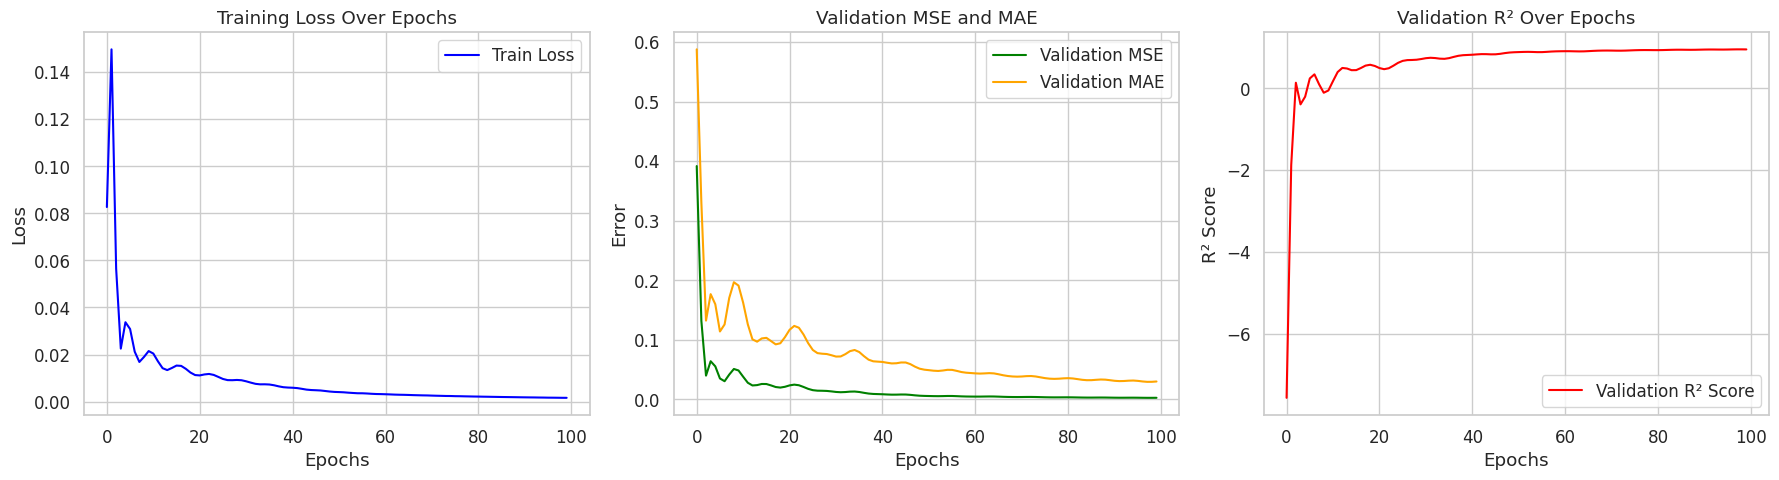

In [34]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_mses, label='Validation MSE', color='green')
plt.plot(val_maes, label='Validation MAE', color='orange')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Validation MSE and MAE")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_r2s, label='Validation R² Score', color='red')
plt.xlabel("Epochs")
plt.ylabel("R² Score")
plt.title("Validation R² Over Epochs")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


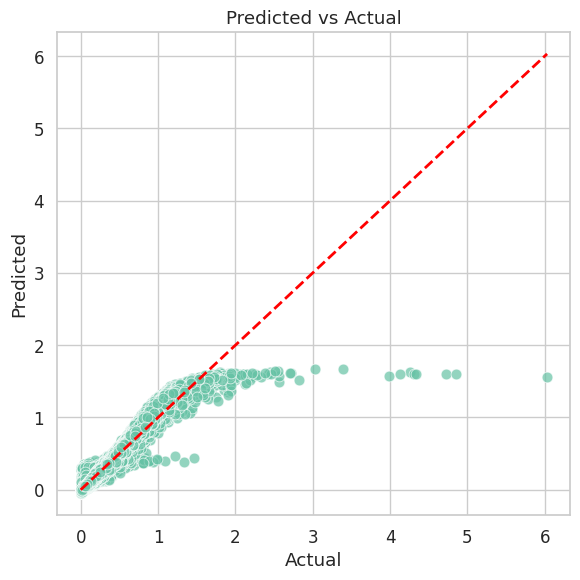

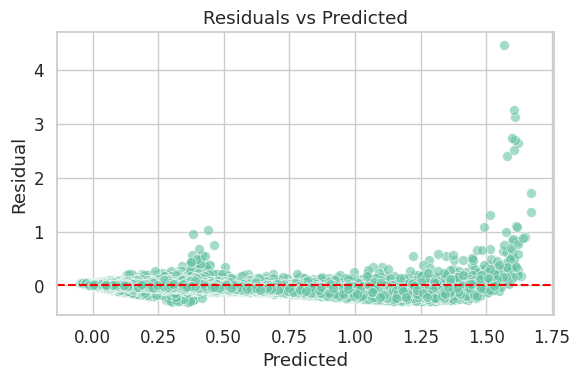

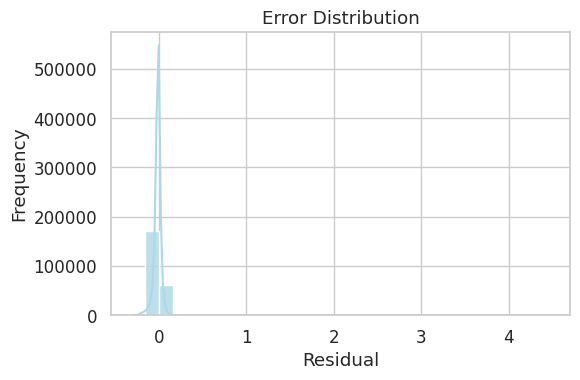

In [35]:
# 🎯 Get predictions
model.eval()
with torch.no_grad():
    y_pred = model(data_val).cpu().numpy()
    y_true = data_val.y.cpu().numpy()
    residuals = y_true - y_pred

# ➤ 1. Predicted vs Actual
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_true, y=y_pred, s=60, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.show()

# ➤ 2. Residuals vs Predicted
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, s=50, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

# ➤ 3. Error Distribution
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, kde=True, color='lightblue', edgecolor=None, alpha=0.8)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.tight_layout()
plt.show()

In [36]:
# Calculate the average of last N epochs
N = 10  # You can change this to 5 or 20

avg_train_loss = sum(train_losses[-N:]) / N
avg_val_mse = sum(val_mses[-N:]) / N

print(f"\n📊 Last {N} Epochs Average:")
print(f"  ➤ Train Loss: {avg_train_loss:.4f}")
print(f"  ➤ Validation MSE: {avg_val_mse:.4f}")

# Simple overfitting check
if avg_train_loss < avg_val_mse * 0.7:
    print("⚠️ Possible Overfitting: Training loss is much lower than validation loss.")
elif avg_val_mse < avg_train_loss:
    print("✅ Good: Validation error is even lower than training (unlikely, but good).")
else:
    print("👍 Balanced: No strong signs of overfitting.")


📊 Last 10 Epochs Average:
  ➤ Train Loss: 0.0018
  ➤ Validation MSE: 0.0024
👍 Balanced: No strong signs of overfitting.


GNN(GCN)+Transformer+BiLSTM

In [37]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


In [38]:
class GNNTransformerBiLSTMModel(nn.Module):
    def __init__(self, input_dim, gnn_hidden=64, trans_hidden=64, n_heads=4,
                 n_transformer_layers=2, lstm_hidden_dim=32, lstm_layers=1):
        super().__init__()

        # GNN (simple 2-layer GCN)
        self.gcn1 = GCNConv(input_dim, gnn_hidden)
        self.gcn2 = GCNConv(gnn_hidden, gnn_hidden)

        # Linear projection
        self.input_proj = nn.Linear(gnn_hidden, trans_hidden)

        # Positional Encoding & Transformer
        self.pos_encoder = PositionalEncoding(trans_hidden)
        encoder_layer = nn.TransformerEncoderLayer(d_model=trans_hidden, nhead=n_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)

        self.norm_trans = nn.LayerNorm(trans_hidden)
        self.dropout_trans = nn.Dropout(0.2)

        # BiLSTM
        self.bilstm = nn.LSTM(
            input_size=trans_hidden,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True
        )
        self.norm_lstm = nn.LayerNorm(2 * lstm_hidden_dim)
        self.dropout_lstm = nn.Dropout(0.2)

        # Final regression
        total_dim = trans_hidden + 2 * lstm_hidden_dim
        self.regressor = nn.Sequential(
            nn.Linear(total_dim, trans_hidden),
            nn.ReLU(),
            nn.Linear(trans_hidden, 1)
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # GNN layers
        x = torch.relu(self.gcn1(x, edge_index))
        x = torch.relu(self.gcn2(x, edge_index))

        # Project + positional encoding
        x = self.input_proj(x)
        x = x.unsqueeze(1)  # [N, 1, D]
        x = self.pos_encoder(x)

        # Transformer
        x_trans = self.transformer(x).mean(dim=1)
        x_trans = self.norm_trans(self.dropout_trans(x_trans))

        # BiLSTM
        lstm_out, _ = self.bilstm(x)
        x_lstm = lstm_out.mean(dim=1)
        x_lstm = self.norm_lstm(self.dropout_lstm(x_lstm))

        # Concatenate
        combined = torch.cat([x_trans, x_lstm], dim=1)
        return self.regressor(combined).view(-1)

In [39]:
from torch_geometric.nn import GCNConv
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_train = data_train.to(device)
data_val = data_val.to(device)

model = GNNTransformerBiLSTMModel(input_dim=data_train.num_node_features).to(device)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

In [40]:
def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        y_pred = model(data).cpu().numpy()
        y_true = data.y.cpu().numpy()
        return {
            "MSE": mean_squared_error(y_true, y_pred),
            "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)
        }

# 🏋️ Training
epochs = 100
train_losses, val_mses, val_maes, val_r2s = [], [], [], []
best_r2 = float("-inf")
best_model_state = None

print("📦 Starting training for GNN+Transformer+BiLSTM...")
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    pred = model(data_train)
    loss = criterion(pred, data_train.y)
    loss.backward()
    optimizer.step()

    val_scores = evaluate(model, data_val)

    train_losses.append(loss.item())
    val_mses.append(val_scores["MSE"])
    val_maes.append(val_scores["MAE"])
    val_r2s.append(val_scores["R2"])

    if val_scores["R2"] > best_r2:
        best_r2 = val_scores["R2"]
        best_model_state = model.state_dict()

    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch:03d}] Train Loss: {loss.item():.4f} | Val MSE: {val_scores['MSE']:.4f} | Val MAE: {val_scores['MAE']:.4f} | Val R2: {val_scores['R2']:.4f}")

model.load_state_dict(best_model_state)
print(f"\n✅ Training complete. Best R2: {best_r2:.4f}")

📦 Starting training for GNN+Transformer+BiLSTM...
[Epoch 001] Train Loss: 0.2161 | Val MSE: 0.4653 | Val MAE: 0.6540 | Val R2: -9.1735
[Epoch 005] Train Loss: 0.0785 | Val MSE: 0.0887 | Val MAE: 0.2127 | Val R2: -0.9390
[Epoch 010] Train Loss: 0.0486 | Val MSE: 0.0568 | Val MAE: 0.1993 | Val R2: -0.2414
[Epoch 015] Train Loss: 0.0540 | Val MSE: 0.0551 | Val MAE: 0.1954 | Val R2: -0.2039
[Epoch 020] Train Loss: 0.0487 | Val MSE: 0.0442 | Val MAE: 0.1536 | Val R2: 0.0332
[Epoch 025] Train Loss: 0.0467 | Val MSE: 0.0446 | Val MAE: 0.1644 | Val R2: 0.0246
[Epoch 030] Train Loss: 0.0458 | Val MSE: 0.0511 | Val MAE: 0.1870 | Val R2: -0.1181
[Epoch 035] Train Loss: 0.0435 | Val MSE: 0.0436 | Val MAE: 0.1655 | Val R2: 0.0460
[Epoch 040] Train Loss: 0.0420 | Val MSE: 0.0395 | Val MAE: 0.1522 | Val R2: 0.1361
[Epoch 045] Train Loss: 0.0388 | Val MSE: 0.0398 | Val MAE: 0.1592 | Val R2: 0.1305
[Epoch 050] Train Loss: 0.0351 | Val MSE: 0.0346 | Val MAE: 0.1456 | Val R2: 0.2439
[Epoch 055] Train Los

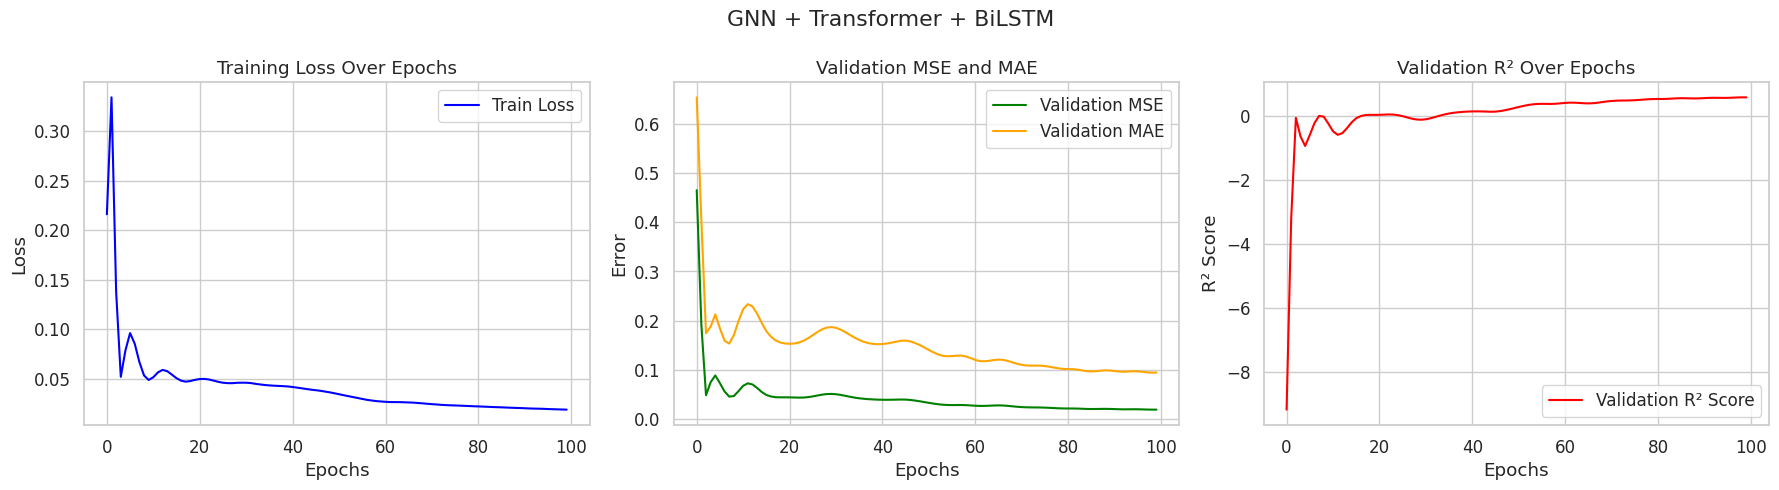

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))
plt.suptitle("GNN + Transformer + BiLSTM")
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_mses, label='Validation MSE', color='green')
plt.plot(val_maes, label='Validation MAE', color='orange')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Validation MSE and MAE")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_r2s, label='Validation R² Score', color='red')
plt.xlabel("Epochs")
plt.ylabel("R² Score")
plt.title("Validation R² Over Epochs")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


GNN + Transformer + BiLSTM Model Evaluation


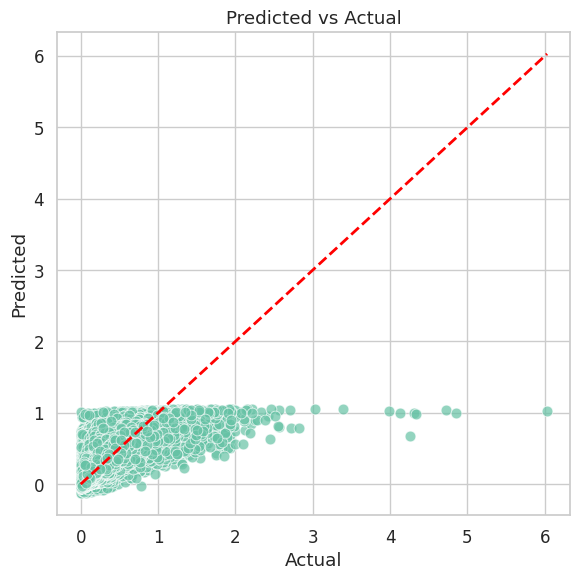

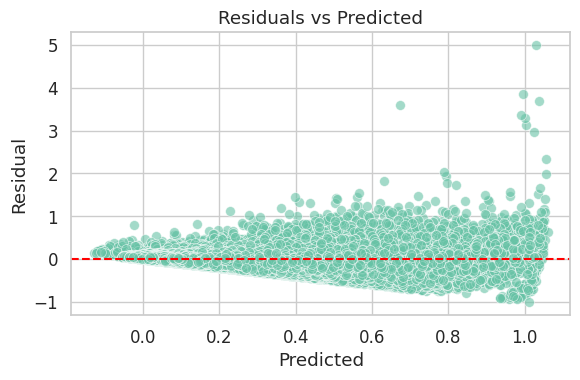

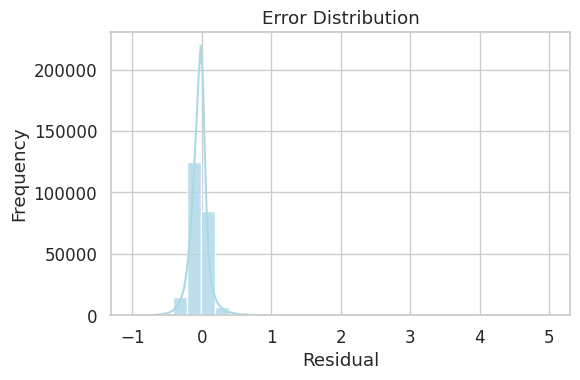

In [42]:
# 🎯 Get predictions
model.eval()
with torch.no_grad():
    y_pred = model(data_val).cpu().numpy()
    y_true = data_val.y.cpu().numpy()
    residuals = y_true - y_pred
print("GNN + Transformer + BiLSTM Model Evaluation")
# ➤ 1. Predicted vs Actual
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_true, y=y_pred, s=60, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.show()

# ➤ 2. Residuals vs Predicted
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, s=50, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

# ➤ 3. Error Distribution
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, kde=True, color='lightblue', edgecolor=None, alpha=0.8)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.tight_layout()
plt.show()

In [43]:
# Calculate the average of last N epochs
N = 10  # You can change this to 5 or 20

avg_train_loss = sum(train_losses[-N:]) / N
avg_val_mse = sum(val_mses[-N:]) / N

print(f"\n📊 Last {N} Epochs Average:")
print(f"  ➤ Train Loss: {avg_train_loss:.4f}")
print(f"  ➤ Validation MSE: {avg_val_mse:.4f}")

# Simple overfitting check
if avg_train_loss < avg_val_mse * 0.7:
    print("⚠️ Possible Overfitting: Training loss is much lower than validation loss.")
elif avg_val_mse < avg_train_loss:
    print("✅ Good: Validation error is even lower than training (unlikely, but good).")
else:
    print("👍 Balanced: No strong signs of overfitting.")



📊 Last 10 Epochs Average:
  ➤ Train Loss: 0.0193
  ➤ Validation MSE: 0.0197
👍 Balanced: No strong signs of overfitting.


IMPROVED CODE (Experimental purpose)

In [44]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [45]:
class GNNTransformerBiLSTMModel1(nn.Module):
    def __init__(self, input_dim, gnn_hidden=64, trans_hidden=64, n_heads=4, n_transformer_layers=2,
                 lstm_hidden_dim=32, lstm_layers=1):
        super().__init__()
        self.gcn1 = GCNConv(input_dim, gnn_hidden)
        self.gcn2 = GCNConv(gnn_hidden, gnn_hidden)

        self.input_proj = nn.Linear(gnn_hidden, trans_hidden)
        self.pos_encoder = PositionalEncoding(trans_hidden)

        encoder_layer = nn.TransformerEncoderLayer(d_model=trans_hidden, nhead=n_heads,
                                                   batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)

        self.bilstm = nn.LSTM(
            input_size=trans_hidden,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True
        )

        total_dim = trans_hidden + 2 * lstm_hidden_dim
        self.regressor = nn.Sequential(
            nn.Linear(total_dim, trans_hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(trans_hidden, 1)
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = torch.relu(self.gcn1(x, edge_index))
        x = torch.relu(self.gcn2(x, edge_index))
        x = x.view(-1, 1, x.size(1))
        x = self.input_proj(x)
        x = self.pos_encoder(x)

        x_trans = self.transformer(x).mean(dim=1)
        lstm_out, _ = self.bilstm(x)
        x_lstm = lstm_out.mean(dim=1)

        combined = torch.cat([x_trans, x_lstm], dim=1)
        return self.regressor(combined).view(-1)


In [46]:
model = GNNTransformerBiLSTMModel1(input_dim=data_train.num_node_features).to(device)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10, verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [47]:
def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        y_pred = model(data).cpu().numpy()
        y_true = data.y.cpu().numpy()
        return {
            "MSE": mean_squared_error(y_true, y_pred),
            "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)
        }

model_name="GNN+Transformer+BiLSTM"
# Training Loop
train_losses, val_r2s, val_maes, val_mses = [], [], [], []
epochs = 200
best_r2 = float('-inf')
best_model_state = None
patience = 30
epochs_no_improve = 0

print("\n📦 Starting training for GNN+Transformer+BiLSTM...")
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    pred = model(data_train)
    loss = criterion(pred, data_train.y)
    loss.backward()
    optimizer.step()

    val_scores = evaluate(model, data_val)
    scheduler.step(val_scores['R2'])

    train_losses.append(loss.item())
    val_r2s.append(val_scores['R2'])
    val_maes.append(val_scores['MAE'])
    val_mses.append(val_scores['MSE'])

    if val_scores['R2'] > best_r2:
        best_r2 = val_scores['R2']
        best_model_state = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch:03d}] Train Loss: {loss.item():.4f} | Val MSE: {val_scores['MSE']:.4f} | "
              f"Val MAE: {val_scores['MAE']:.4f} | Val R2: {val_scores['R2']:.4f}")

    if epochs_no_improve >= patience:
        print(f"\n🛑 Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_model_state)
print(f"\n✅ Training complete. Best R2: {best_r2:.4f}")

results[model_name] = {
    "model": deepcopy(model),
    "R2": best_r2,
    "MSE": val_mses[-1],
    "MAE": val_maes[-1]
}


📦 Starting training for GNN+Transformer+BiLSTM...
[Epoch 001] Train Loss: 0.0513 | Val MSE: 0.4903 | Val MAE: 0.6728 | Val R2: -9.7201
[Epoch 005] Train Loss: 0.0749 | Val MSE: 0.0605 | Val MAE: 0.1654 | Val R2: -0.3226
[Epoch 010] Train Loss: 0.0536 | Val MSE: 0.0512 | Val MAE: 0.1835 | Val R2: -0.1186
[Epoch 015] Train Loss: 0.0475 | Val MSE: 0.0475 | Val MAE: 0.1542 | Val R2: -0.0386
[Epoch 020] Train Loss: 0.0467 | Val MSE: 0.0456 | Val MAE: 0.1592 | Val R2: 0.0033
[Epoch 025] Train Loss: 0.0468 | Val MSE: 0.0465 | Val MAE: 0.1672 | Val R2: -0.0170
[Epoch 030] Train Loss: 0.0460 | Val MSE: 0.0455 | Val MAE: 0.1573 | Val R2: 0.0048
[Epoch 035] Train Loss: 0.0460 | Val MSE: 0.0453 | Val MAE: 0.1574 | Val R2: 0.0090
[Epoch 040] Train Loss: 0.0456 | Val MSE: 0.0454 | Val MAE: 0.1623 | Val R2: 0.0076
[Epoch 045] Train Loss: 0.0451 | Val MSE: 0.0447 | Val MAE: 0.1583 | Val R2: 0.0225
[Epoch 050] Train Loss: 0.0445 | Val MSE: 0.0439 | Val MAE: 0.1555 | Val R2: 0.0411
[Epoch 055] Train Lo

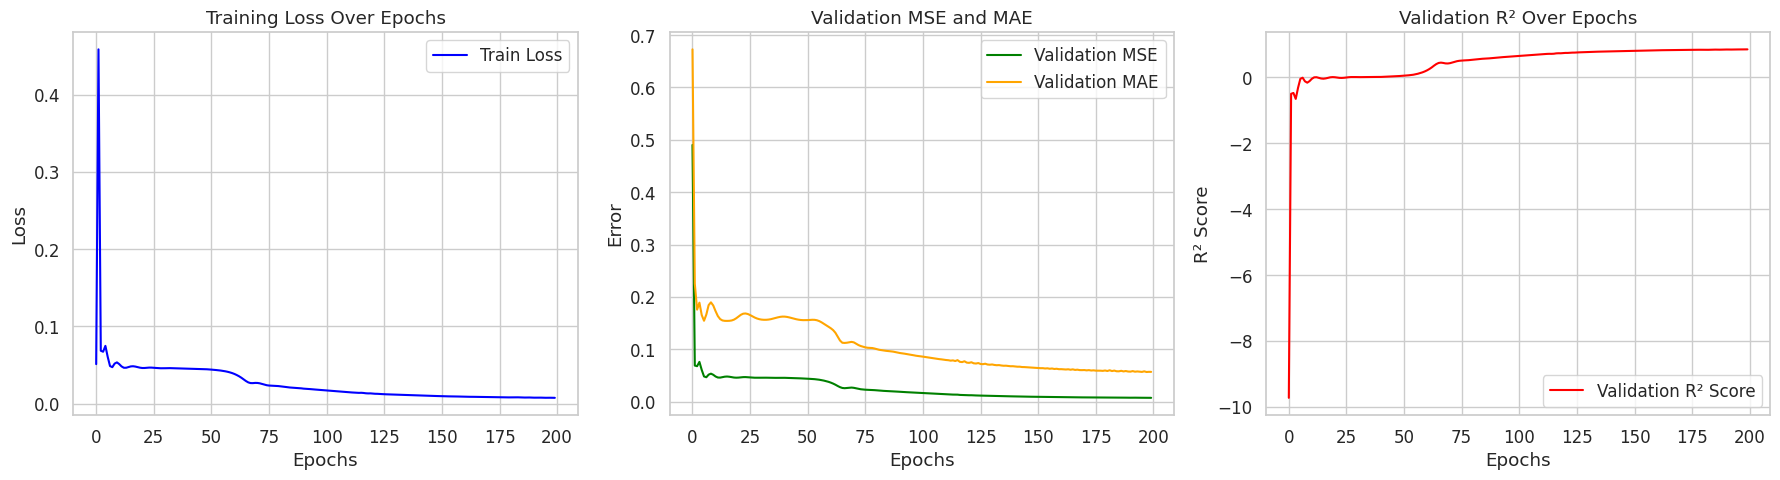

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_mses, label='Validation MSE', color='green')
plt.plot(val_maes, label='Validation MAE', color='orange')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Validation MSE and MAE")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_r2s, label='Validation R² Score', color='red')
plt.xlabel("Epochs")
plt.ylabel("R² Score")
plt.title("Validation R² Over Epochs")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

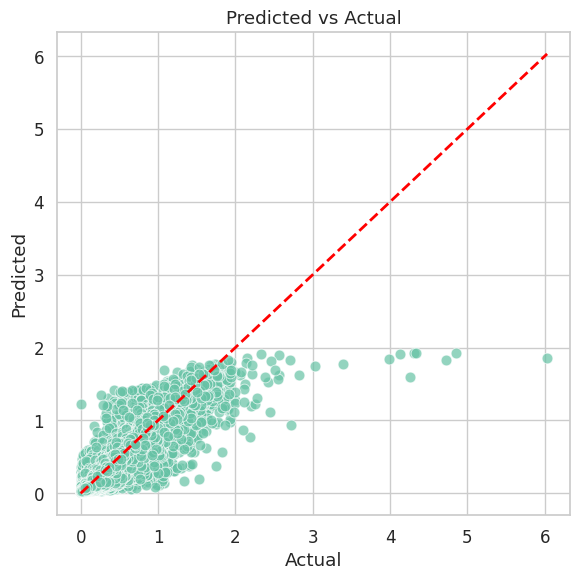

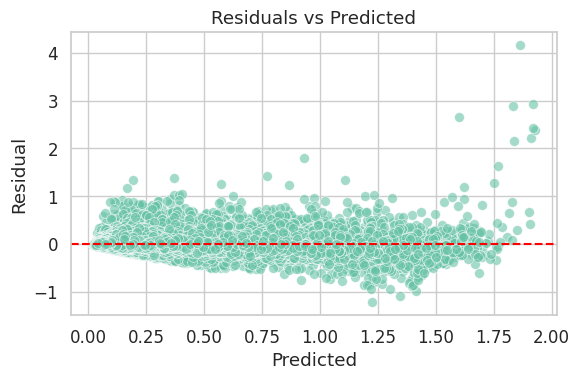

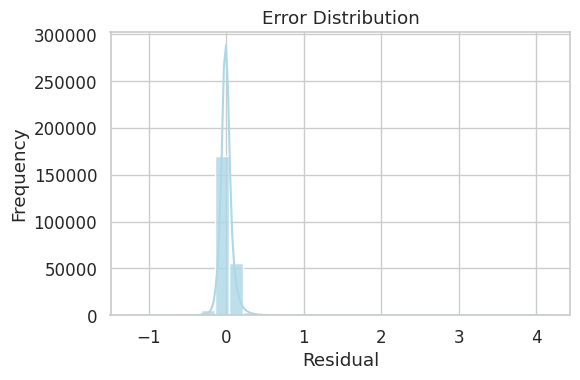

In [49]:
# 🎯 Get predictions
model.eval()
with torch.no_grad():
    y_pred = model(data_val).cpu().numpy()
    y_true = data_val.y.cpu().numpy()
    residuals = y_true - y_pred

# ➤ 1. Predicted vs Actual
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_true, y=y_pred, s=60, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.show()

# ➤ 2. Residuals vs Predicted
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, s=50, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

# ➤ 3. Error Distribution
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, kde=True, color='lightblue', edgecolor=None, alpha=0.8)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.tight_layout()
plt.show()

In [50]:
# Calculate the average of last N epochs
N = 10  # You can change this to 5 or 20

avg_train_loss = sum(train_losses[-N:]) / N
avg_val_mse = sum(val_mses[-N:]) / N

print(f"\n📊 Last {N} Epochs Average:")
print(f"  ➤ Train Loss: {avg_train_loss:.4f}")
print(f"  ➤ Validation MSE: {avg_val_mse:.4f}")

# Simple overfitting check
if avg_train_loss < avg_val_mse * 0.7:
    print("⚠️ Possible Overfitting: Training loss is much lower than validation loss.")
elif avg_val_mse < avg_train_loss:
    print("✅ Good: Validation error is even lower than training (unlikely, but good).")
else:
    print("👍 Balanced: No strong signs of overfitting.")


📊 Last 10 Epochs Average:
  ➤ Train Loss: 0.0079
  ➤ Validation MSE: 0.0073
✅ Good: Validation error is even lower than training (unlikely, but good).


Improvement in transformer+ biLSTM using AttentionPooling

In [51]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


In [52]:
class AttentionPooling(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.attn = nn.Linear(input_dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)  # [batch, seq_len, 1]
        return torch.sum(weights * x, dim=1)

In [53]:
class TransformerBiLSTMModelWithAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, n_heads=4, n_transformer_layers=1,
                 lstm_hidden_dim=32, lstm_layers=1, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=n_heads, batch_first=True,
            dropout=dropout, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)

        self.bilstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0
        )

        self.attn_pool_trans = AttentionPooling(hidden_dim)
        self.attn_pool_lstm = AttentionPooling(2 * lstm_hidden_dim)

        total_dim = hidden_dim + 2 * lstm_hidden_dim
        self.regressor = nn.Sequential(
            nn.LayerNorm(total_dim),
            nn.Linear(total_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x = data.x.view(-1, 1, data.num_node_features)
        x = self.input_proj(x)
        x = self.pos_encoder(x)

        x_trans = self.transformer(x)
        pooled_trans = self.attn_pool_trans(x_trans)

        lstm_out, _ = self.bilstm(x)
        pooled_lstm = self.attn_pool_lstm(lstm_out)

        combined = torch.cat([pooled_trans, pooled_lstm], dim=1)
        return self.regressor(combined).view(-1)

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_train = data_train.to(device)
data_val = data_val.to(device)

model = TransformerBiLSTMModelWithAttention(input_dim=data_train.num_node_features).to(device)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [55]:
def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        y_pred = model(data).cpu().numpy()
        y_true = data.y.cpu().numpy()
        return {
            "MSE": mean_squared_error(y_true, y_pred),
            "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)
        }

model_name="Transformer+BiLSTM Model with Attention Pooling"
train_losses = []
val_r2s = []
val_maes = []
val_mses = []

epochs = 200
patience = 30
best_r2 = float("-inf")
best_model_state = None
patience_counter = 0

print("📦 Starting training for Transformer+BiLSTM with Attention Pooling...")
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    pred = model(data_train)
    loss = criterion(pred, data_train.y)
    loss.backward()
    optimizer.step()

    val_scores = evaluate(model, data_val)
    train_losses.append(loss.item())
    val_r2s.append(val_scores["R2"])
    val_maes.append(val_scores["MAE"])
    val_mses.append(val_scores["MSE"])

    if val_scores["R2"] > best_r2:
        best_r2 = val_scores["R2"]
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch:03d}] Train Loss: {loss.item():.4f} | "
              f"Val MSE: {val_scores['MSE']:.4f} | MAE: {val_scores['MAE']:.4f} | R2: {val_scores['R2']:.4f}")

    if patience_counter >= patience:
        print(f"⏹️ Early stopping triggered at epoch {epoch}.")
        break

model.load_state_dict(best_model_state)
print(f"✅ Training complete. Best R2: {best_r2:.4f}")

results[model_name] = {
    "model": deepcopy(model),
    "R2": best_r2,
    "MSE": val_mses[-1],
    "MAE": val_maes[-1]
}

📦 Starting training for Transformer+BiLSTM with Attention Pooling...
[Epoch 001] Train Loss: 0.2476 | Val MSE: 0.1550 | MAE: 0.3534 | R2: -2.3889
[Epoch 005] Train Loss: 0.0682 | Val MSE: 0.0539 | MAE: 0.1707 | R2: -0.1794
[Epoch 010] Train Loss: 0.0426 | Val MSE: 0.0366 | MAE: 0.1651 | R2: 0.2003
[Epoch 015] Train Loss: 0.0280 | Val MSE: 0.0219 | MAE: 0.0997 | R2: 0.5211
[Epoch 020] Train Loss: 0.0206 | Val MSE: 0.0160 | MAE: 0.0917 | R2: 0.6500
[Epoch 025] Train Loss: 0.0175 | Val MSE: 0.0111 | MAE: 0.0683 | R2: 0.7571
[Epoch 030] Train Loss: 0.0155 | Val MSE: 0.0092 | MAE: 0.0590 | R2: 0.7999
[Epoch 035] Train Loss: 0.0130 | Val MSE: 0.0082 | MAE: 0.0612 | R2: 0.8215
[Epoch 040] Train Loss: 0.0105 | Val MSE: 0.0062 | MAE: 0.0485 | R2: 0.8649
[Epoch 045] Train Loss: 0.0090 | Val MSE: 0.0054 | MAE: 0.0465 | R2: 0.8828
[Epoch 050] Train Loss: 0.0078 | Val MSE: 0.0041 | MAE: 0.0375 | R2: 0.9109
[Epoch 055] Train Loss: 0.0070 | Val MSE: 0.0036 | MAE: 0.0375 | R2: 0.9204
[Epoch 060] Train

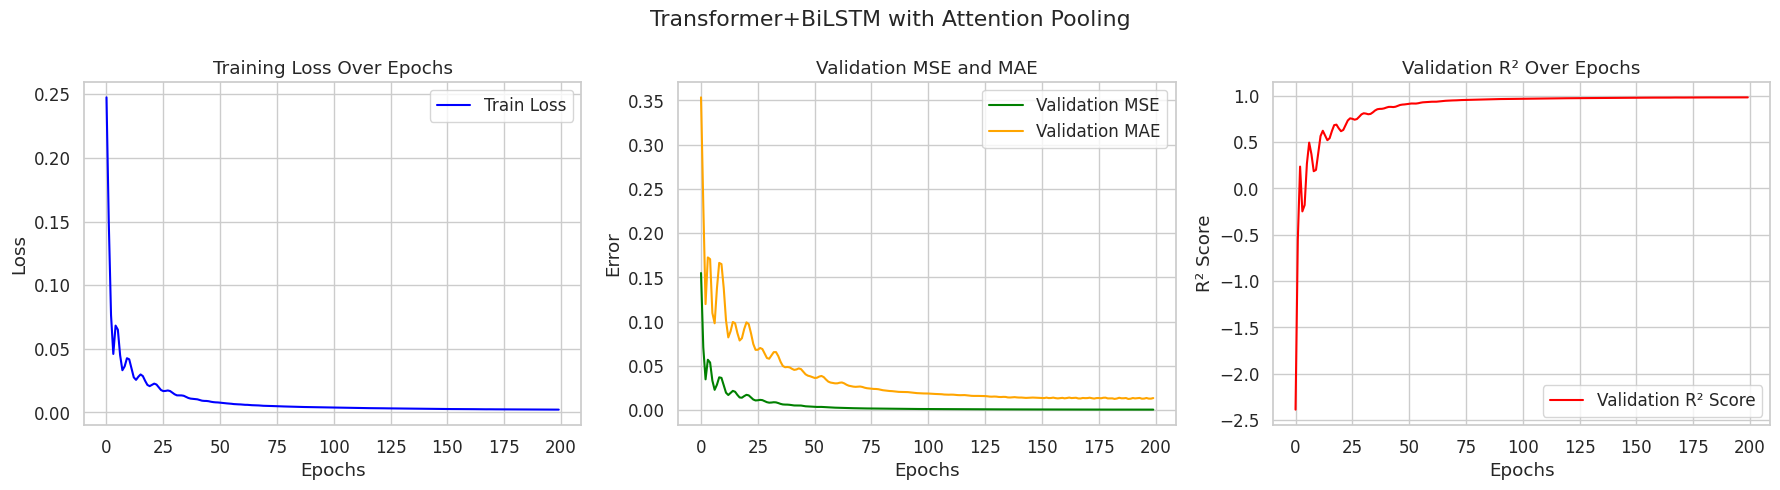

In [56]:
plt.figure(figsize=(18, 5))
plt.suptitle("Transformer+BiLSTM with Attention Pooling")
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_mses, label='Validation MSE', color='green')
plt.plot(val_maes, label='Validation MAE', color='orange')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Validation MSE and MAE")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_r2s, label='Validation R² Score', color='red')
plt.xlabel("Epochs")
plt.ylabel("R² Score")
plt.title("Validation R² Over Epochs")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Transformer+BiLSTM with Attention Pooling Model Evaluation


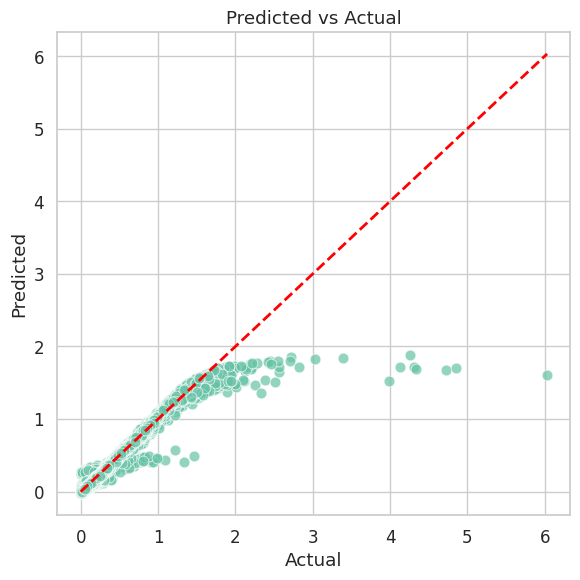

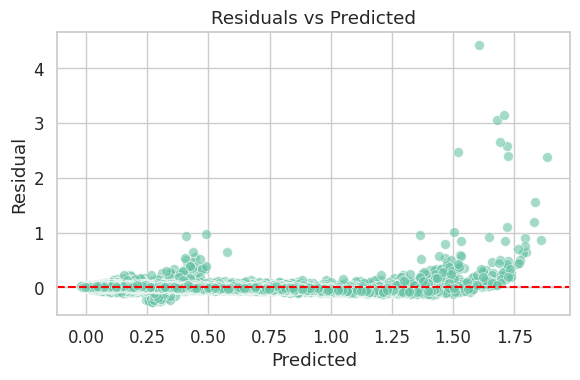

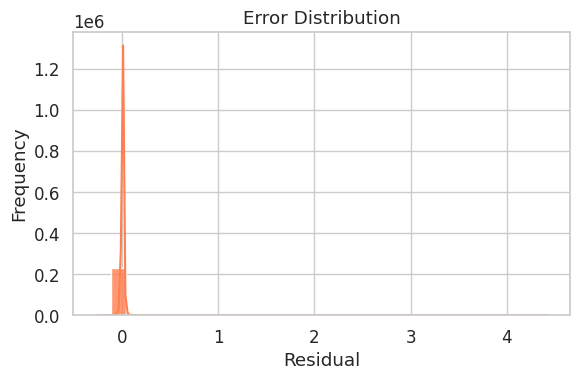

In [57]:
import seaborn as sns
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

# 🎯 Get predictions
model.eval()
with torch.no_grad():
    y_pred = model(data_val).cpu().numpy()
    y_true = data_val.y.cpu().numpy()
    residuals = y_true - y_pred
print("Transformer+BiLSTM with Attention Pooling Model Evaluation")
# ➤ 1. Predicted vs Actual
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_true, y=y_pred, s=60, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.show()

# ➤ 2. Residuals vs Predicted
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, s=50, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

# ➤ 3. Error Distribution
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, kde=True, color='coral', edgecolor=None, alpha=0.8)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.tight_layout()
plt.show()

In [58]:
# Calculate the average of last N epochs
N = 10  # You can change this to 5 or 20

avg_train_loss = sum(train_losses[-N:]) / N
avg_val_mse = sum(val_mses[-N:]) / N

print(f"\n📊 Last {N} Epochs Average:")
print(f"  ➤ Train Loss: {avg_train_loss:.4f}")
print(f"  ➤ Validation MSE: {avg_val_mse:.4f}")

# Simple overfitting check
if avg_train_loss < avg_val_mse * 0.7:
    print("⚠️ Possible Overfitting: Training loss is much lower than validation loss.")
elif avg_val_mse < avg_train_loss:
    print("✅ Good: Validation error is even lower than training (unlikely, but good).")
else:
    print("👍 Balanced: No strong signs of overfitting.")


📊 Last 10 Epochs Average:
  ➤ Train Loss: 0.0022
  ➤ Validation MSE: 0.0008
✅ Good: Validation error is even lower than training (unlikely, but good).


MLP

In [59]:
class MLPModel(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32], dropout=0.1):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, data):
        x = data.x.view(-1, data.num_node_features)
        return self.net(x).view(-1)


In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_train = data_train.to(device)
data_val = data_val.to(device)

model = MLPModel(input_dim=data_train.num_node_features).to(device)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

In [61]:
def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        y_pred = model(data).cpu().numpy()
        y_true = data.y.cpu().numpy()
        return {
            "MSE": mean_squared_error(y_true, y_pred),
            "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)
        }

model_name="MLP Model"
train_losses = []
val_r2s = []
val_maes = []
val_mses = []

epochs = 200
patience = 30
best_r2 = float("-inf")
best_model_state = None
patience_counter = 0

print("📦 Starting training for MLP...")
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    pred = model(data_train)
    loss = criterion(pred, data_train.y)
    loss.backward()
    optimizer.step()

    val_scores = evaluate(model, data_val)
    train_losses.append(loss.item())
    val_r2s.append(val_scores["R2"])
    val_maes.append(val_scores["MAE"])
    val_mses.append(val_scores["MSE"])

    if val_scores["R2"] > best_r2:
        best_r2 = val_scores["R2"]
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch:03d}] Train Loss: {loss.item():.4f} | "
              f"Val MSE: {val_scores['MSE']:.4f} | MAE: {val_scores['MAE']:.4f} | R2: {val_scores['R2']:.4f}")

    if patience_counter >= patience:
        print(f"⏹️ Early stopping triggered at epoch {epoch}.")
        break

model.load_state_dict(best_model_state)
print(f"✅ Training complete. Best R2: {best_r2:.4f}")

results[model_name] = {
    "model": deepcopy(model),
    "R2": best_r2,
    "MSE": val_mses[-1],
    "MAE": val_maes[-1]
}

📦 Starting training for MLP...
[Epoch 001] Train Loss: 0.1769 | Val MSE: 0.1600 | MAE: 0.3450 | R2: -2.4976
[Epoch 005] Train Loss: 0.1227 | Val MSE: 0.1098 | MAE: 0.2736 | R2: -1.4006
[Epoch 010] Train Loss: 0.0754 | Val MSE: 0.0659 | MAE: 0.1900 | R2: -0.4401
[Epoch 015] Train Loss: 0.0491 | Val MSE: 0.0420 | MAE: 0.1338 | R2: 0.0818
[Epoch 020] Train Loss: 0.0388 | Val MSE: 0.0327 | MAE: 0.1155 | R2: 0.2851
[Epoch 025] Train Loss: 0.0328 | Val MSE: 0.0263 | MAE: 0.1084 | R2: 0.4255
[Epoch 030] Train Loss: 0.0257 | Val MSE: 0.0197 | MAE: 0.0960 | R2: 0.5698
[Epoch 035] Train Loss: 0.0210 | Val MSE: 0.0159 | MAE: 0.0858 | R2: 0.6514
[Epoch 040] Train Loss: 0.0189 | Val MSE: 0.0144 | MAE: 0.0806 | R2: 0.6852
[Epoch 045] Train Loss: 0.0173 | Val MSE: 0.0129 | MAE: 0.0765 | R2: 0.7183
[Epoch 050] Train Loss: 0.0159 | Val MSE: 0.0113 | MAE: 0.0727 | R2: 0.7521
[Epoch 055] Train Loss: 0.0150 | Val MSE: 0.0103 | MAE: 0.0702 | R2: 0.7752
[Epoch 060] Train Loss: 0.0141 | Val MSE: 0.0094 | MAE

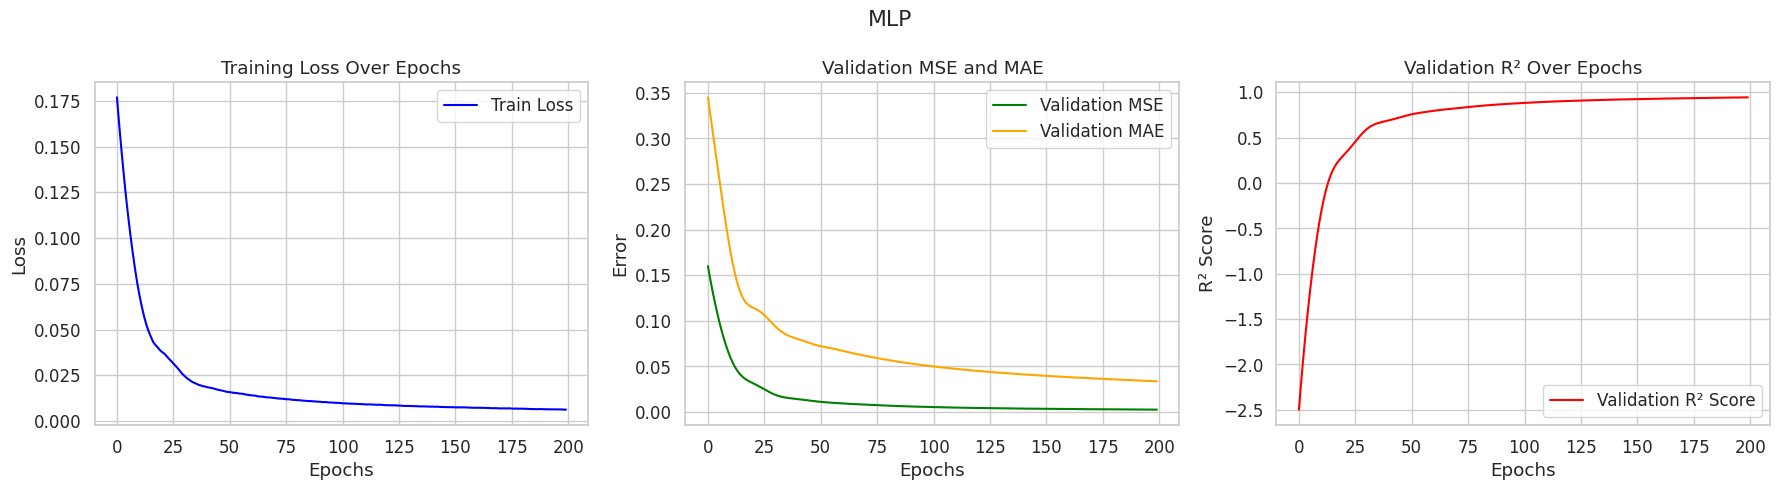

In [62]:
plt.figure(figsize=(18, 5))
plt.suptitle("MLP")
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_mses, label='Validation MSE', color='green')
plt.plot(val_maes, label='Validation MAE', color='orange')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Validation MSE and MAE")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_r2s, label='Validation R² Score', color='red')
plt.xlabel("Epochs")
plt.ylabel("R² Score")
plt.title("Validation R² Over Epochs")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

MLP Model Evaluation


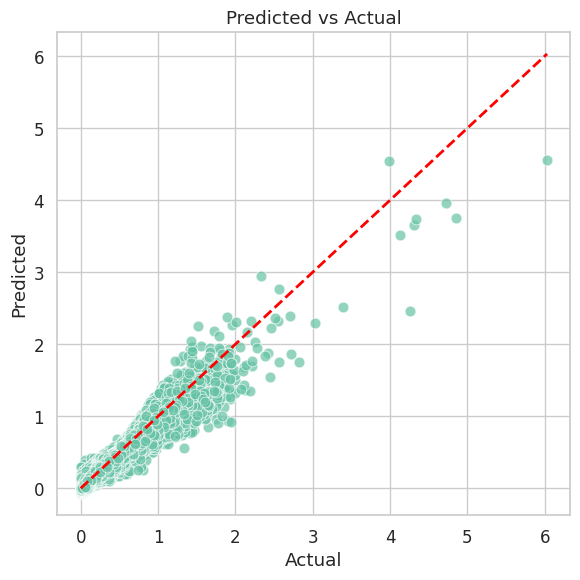

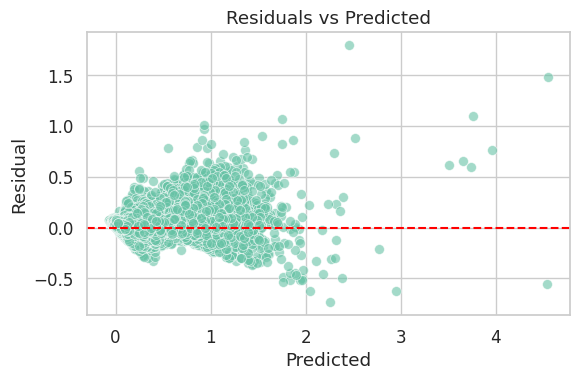

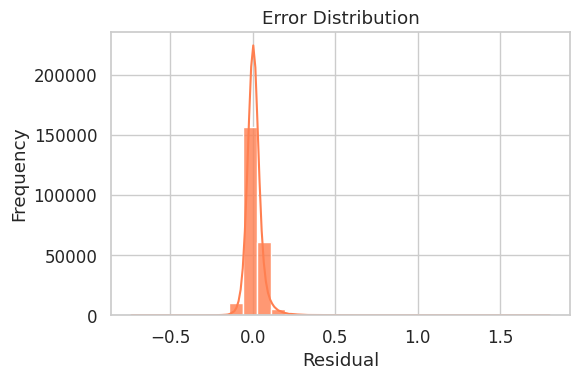

In [63]:
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

# 🎯 Get predictions
model.eval()
with torch.no_grad():
    y_pred = model(data_val).cpu().numpy()
    y_true = data_val.y.cpu().numpy()
    residuals = y_true - y_pred
print("MLP Model Evaluation")
# ➤ 1. Predicted vs Actual
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_true, y=y_pred, s=60, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.show()

# ➤ 2. Residuals vs Predicted
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, s=50, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

# ➤ 3. Error Distribution
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, kde=True, color='coral', edgecolor=None, alpha=0.8)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.tight_layout()
plt.show()

In [64]:
# Calculate the average of last N epochs
N = 10  # You can change this to 5 or 20

avg_train_loss = sum(train_losses[-N:]) / N
avg_val_mse = sum(val_mses[-N:]) / N

print(f"\n📊 Last {N} Epochs Average:")
print(f"  ➤ Train Loss: {avg_train_loss:.4f}")
print(f"  ➤ Validation MSE: {avg_val_mse:.4f}")

# Simple overfitting check
if avg_train_loss < avg_val_mse * 0.7:
    print("⚠️ Possible Overfitting: Training loss is much lower than validation loss.")
elif avg_val_mse < avg_train_loss:
    print("✅ Good: Validation error is even lower than training (unlikely, but good).")
else:
    print("👍 Balanced: No strong signs of overfitting.")


📊 Last 10 Epochs Average:
  ➤ Train Loss: 0.0063
  ➤ Validation MSE: 0.0026
✅ Good: Validation error is even lower than training (unlikely, but good).


/tmp/ipython-input-65-436721164.py:31: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


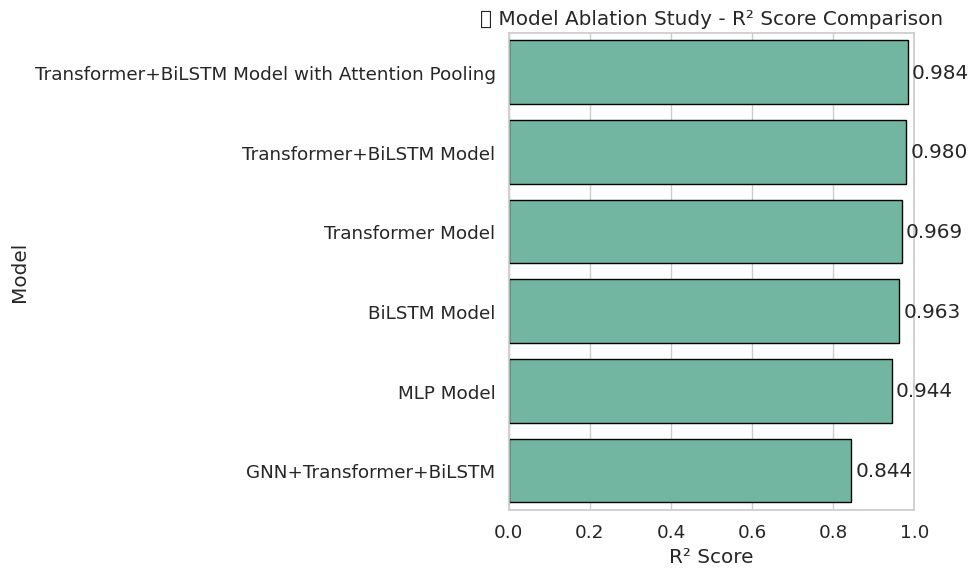


📊 Full Evaluation Metrics by Model:
                                          Model  R² Score    MSE    MAE
Transformer+BiLSTM Model with Attention Pooling    0.9840 0.0007 0.0138
                       Transformer+BiLSTM Model    0.9800 0.0009 0.0168
                              Transformer Model    0.9688 0.0014 0.0219
                                   BiLSTM Model    0.9632 0.0017 0.0242
                                      MLP Model    0.9441 0.0026 0.0336
                         GNN+Transformer+BiLSTM    0.8445 0.0071 0.0567


In [65]:

# 🔍 Build DataFrame from `results` dict
metric_data = []

for model_name, result in results.items():
    metric_data.append({
        "Model": model_name,
        "R² Score": result["R2"],
        "MSE": result["MSE"],
        "MAE": result["MAE"]
    })

df_metrics = pd.DataFrame(metric_data)

# ✅ Sort models by R² score (descending)
df_metrics = df_metrics.sort_values(by="R² Score", ascending=False)

# 🎨 Plot settings
sns.set(style="whitegrid", palette="Set2", font_scale=1.2)
plt.figure(figsize=(10, 6))

# 📊 Horizontal barplot for R² scores
barplot = sns.barplot(x="R² Score", y="Model", data=df_metrics, edgecolor='black')

# ➕ Annotate scores on bars
for i, (r2, model) in enumerate(zip(df_metrics["R² Score"], df_metrics["Model"])):
    barplot.text(r2 + 0.01, i, f"{r2:.3f}", va='center')

plt.title("🔍 Model Ablation Study - R² Score Comparison")
plt.xlabel("R² Score")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# 📋 Print all scores to console
print("\n📊 Full Evaluation Metrics by Model:")
print(df_metrics.to_string(index=False, float_format="%.4f"))


In [66]:
df_all_preds = []

for model_name, res in results.items():
    mdl = deepcopy(res["model"])  # Either full model or load state_dict

    mdl.eval()
    with torch.no_grad():
        y_pred = mdl(data_val).cpu().numpy().flatten()
        y_true = data_val.y.cpu().numpy().flatten()

    df_model = pd.DataFrame({
        "Actual IC50": y_true,
        "Predicted IC50": y_pred,
        "Effect Size": y_true - y_pred,
        "Model": model_name
    })

    df_all_preds.append(df_model)

df_combined = pd.concat(df_all_preds, ignore_index=True)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1412.)
  result = _VF.lstm(


/tmp/ipython-input-75-2448497833.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df_combined.groupby("Model").apply(lambda x: x.sample(n=min(len(x), 2000))).reset_index(drop=True)


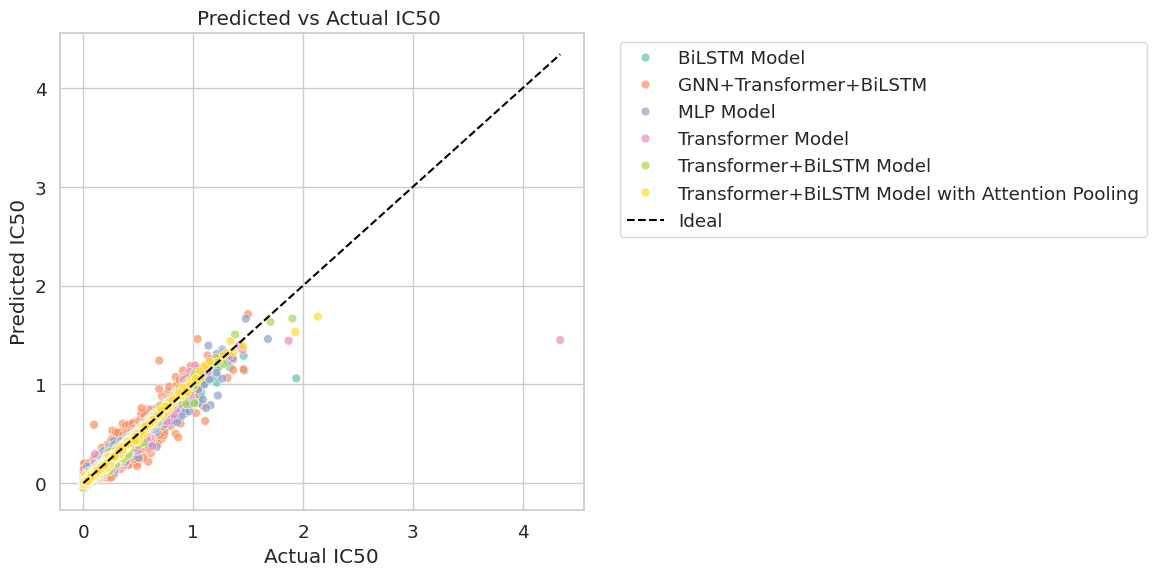

In [75]:
df_sampled = df_combined.groupby("Model").apply(lambda x: x.sample(n=min(len(x), 2000))).reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_sampled, x="Actual IC50", y="Predicted IC50", hue="Model", alpha=0.7, s=40)
plt.plot([df_sampled["Actual IC50"].min(), df_sampled["Actual IC50"].max()],
         [df_sampled["Actual IC50"].min(), df_sampled["Actual IC50"].max()],
         'k--', label="Ideal")
plt.title("Predicted vs Actual IC50 ")
plt.xlabel("Actual IC50")
plt.ylabel("Predicted IC50")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

/tmp/ipython-input-74-1641152902.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_summary = df_sampled.groupby(["IC50 Bin", "Model"]).agg({


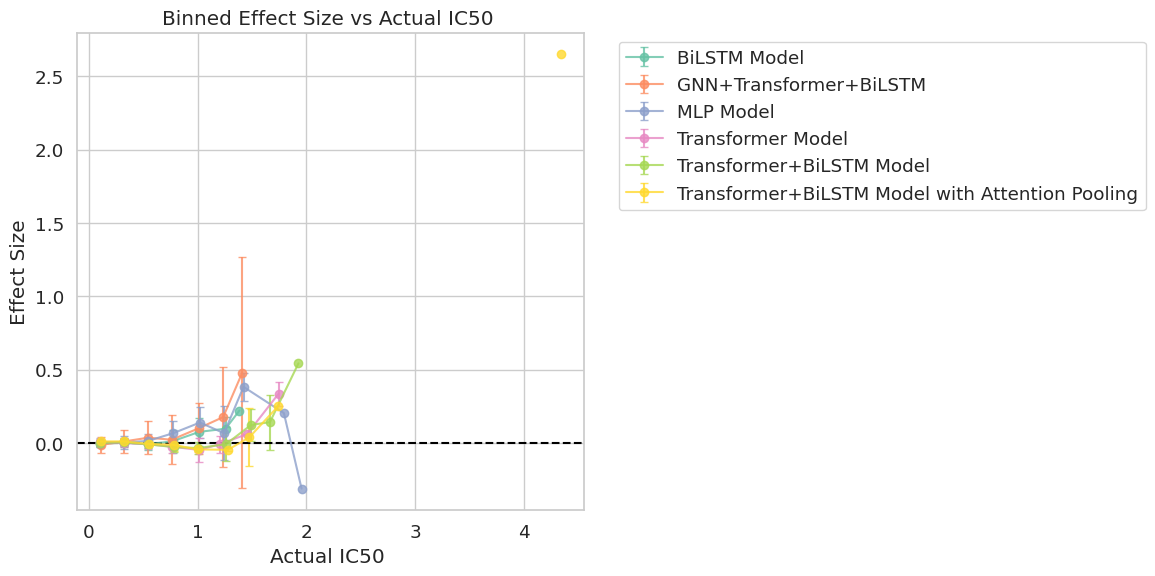

In [74]:

# 🧮 Bin Actual IC50 values
bin_edges = np.linspace(df_sampled["Actual IC50"].min(), df_sampled["Actual IC50"].max(), 20)
df_sampled["IC50 Bin"] = pd.cut(df_sampled["Actual IC50"], bins=bin_edges)

# 📊 Grouped by bin and model
binned_summary = df_sampled.groupby(["IC50 Bin", "Model"]).agg({
    "Effect Size": ["mean", "std"],
    "Actual IC50": "mean"  # midpoint for plotting
}).reset_index()

# 🛠 Flatten MultiIndex columns
binned_summary.columns = ["IC50 Bin", "Model", "EffectMean", "EffectSD", "IC50Mean"]

# 🎨 Plot
plt.figure(figsize=(12, 6))
for model in binned_summary["Model"].unique():
    model_data = binned_summary[binned_summary["Model"] == model]
    plt.errorbar(
        model_data["IC50Mean"],
        model_data["EffectMean"],
        yerr=model_data["EffectSD"],
        label=model,
        fmt='-o',
        capsize=3,
        alpha=0.8
    )

plt.axhline(0, linestyle="--", color="black")
plt.title("Binned Effect Size vs Actual IC50 ")
plt.xlabel("Actual IC50 ")
plt.ylabel("Effect Size")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


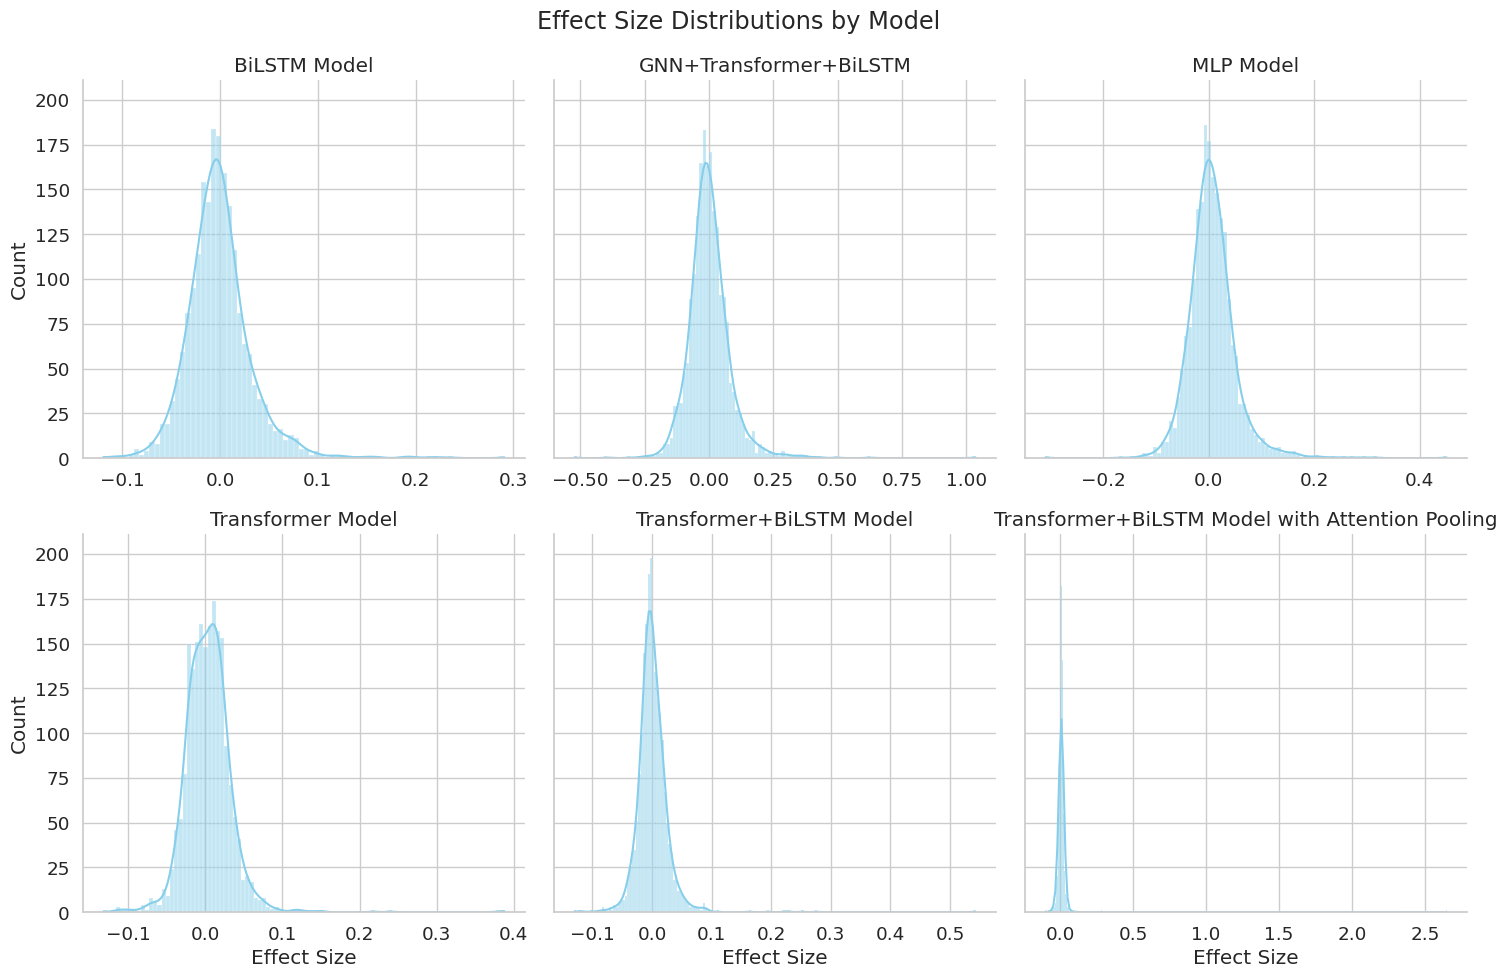

In [71]:
import seaborn as sns
g = sns.FacetGrid(df_sampled, col="Model", col_wrap=3, height=3.5, sharex=False)
g.map_dataframe(sns.histplot, x="Effect Size", kde=True, color="skyblue")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.set_size_inches(15, 10)
g.fig.suptitle("Effect Size Distributions by Model")
plt.tight_layout()
plt.show()

/tmp/ipython-input-76-213769026.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sampled, x="Model", y="Error", palette="Set2")


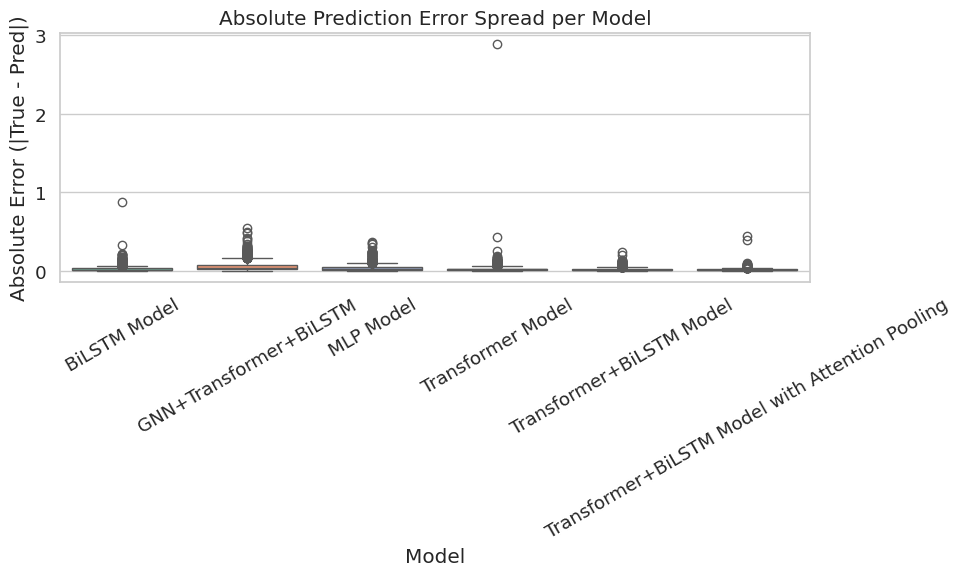

In [76]:
df_sampled["Error"] = np.abs(df_sampled["Actual IC50"] - df_sampled["Predicted IC50"])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sampled, x="Model", y="Error", palette="Set2")
plt.xticks(rotation=30)
plt.title("Absolute Prediction Error Spread per Model")
plt.ylabel("Absolute Error (|True - Pred|)")
plt.tight_layout()
plt.show()

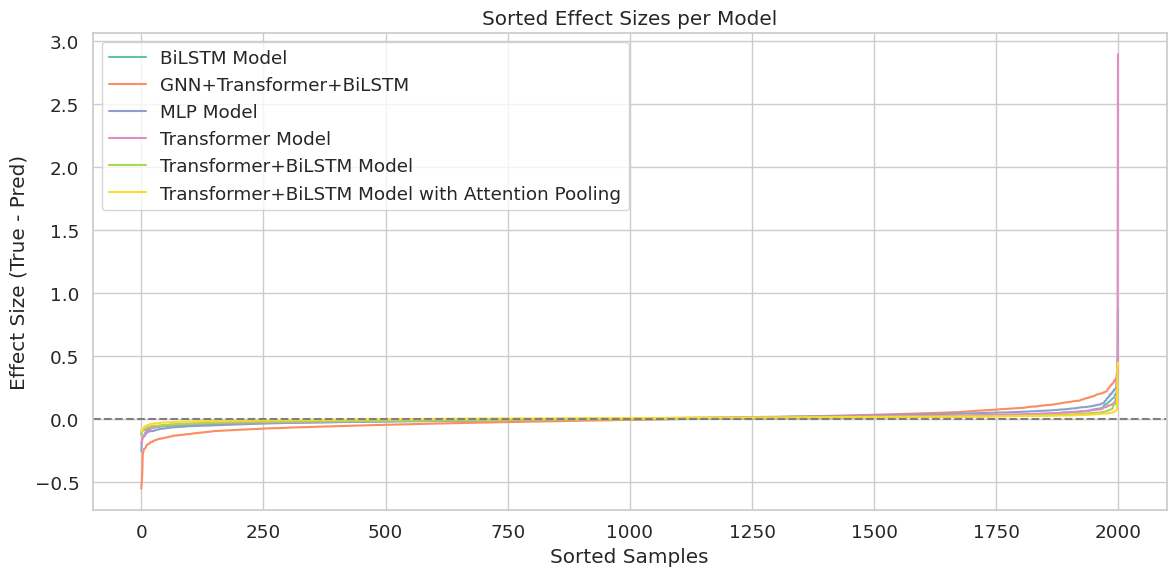

In [77]:

plt.figure(figsize=(12, 6))
for model in df_sampled["Model"].unique():
    subset = df_sampled[df_sampled["Model"] == model]
    sorted_effect = subset["Effect Size"].sort_values().reset_index(drop=True)
    plt.plot(sorted_effect, label=model)

plt.axhline(0, linestyle="--", color="gray")
plt.title("Sorted Effect Sizes per Model")
plt.xlabel("Sorted Samples")
plt.ylabel("Effect Size (True - Pred)")
plt.legend()
plt.tight_layout()
plt.show()

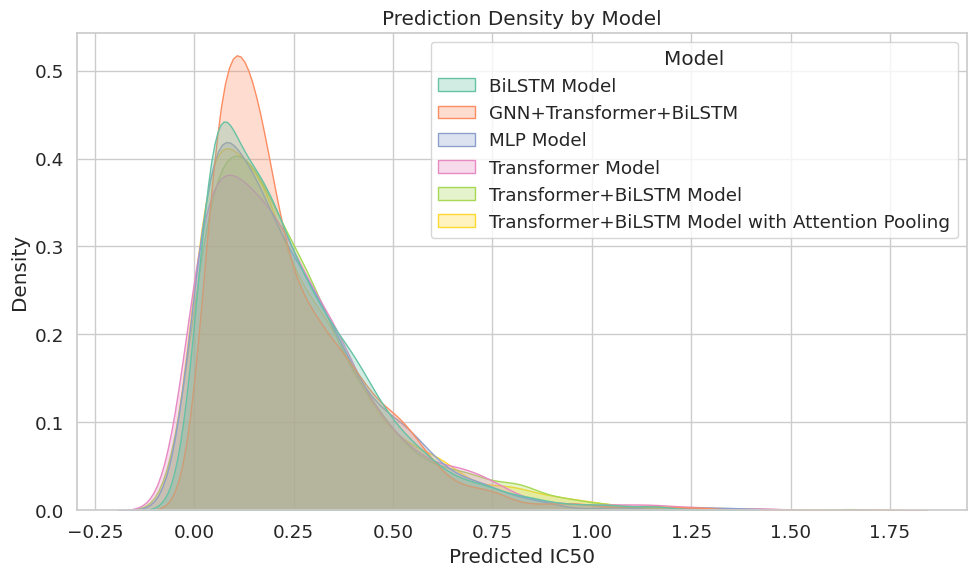

In [78]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_sampled, x="Predicted IC50", hue="Model", fill=True, alpha=0.3)
plt.title("Prediction Density by Model")
plt.xlabel("Predicted IC50")
plt.tight_layout()
plt.show()

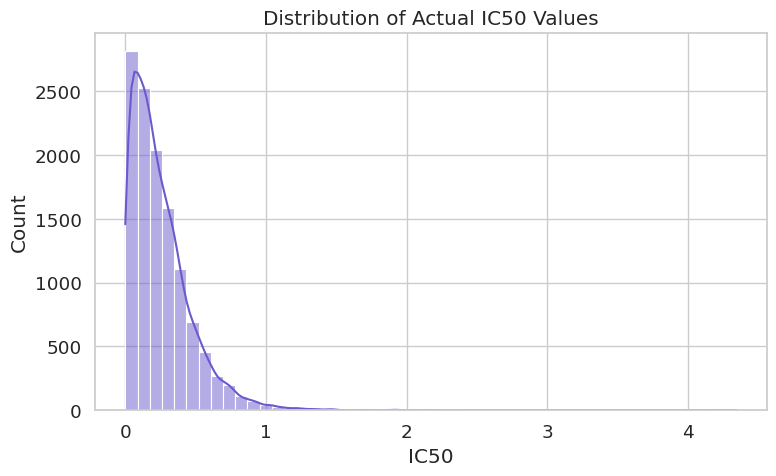

In [79]:
plt.figure(figsize=(8, 5))
sns.histplot(df_sampled["Actual IC50"], bins=50, kde=True, color="slateblue")
plt.title("Distribution of Actual IC50 Values")
plt.xlabel("IC50")
plt.tight_layout()
plt.show()

/tmp/ipython-input-81-4105190060.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_sampled, x="Model", y="Effect Size", palette="Set2", inner="box")


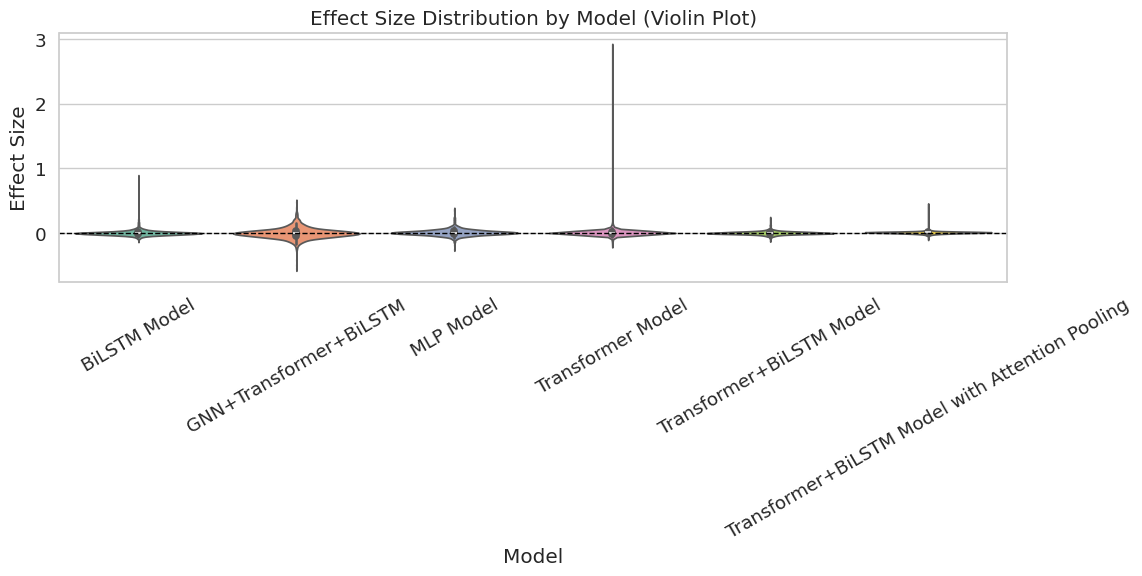

In [81]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_sampled, x="Model", y="Effect Size", palette="Set2", inner="box")
plt.axhline(0, color="black", linestyle="--", lw=1)
plt.xticks(rotation=30)
plt.title("Effect Size Distribution by Model (Violin Plot)")
plt.tight_layout()
plt.show()


/tmp/ipython-input-82-3896137200.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_sampled, x="Model", y="Effect Size", jitter=True, alpha=0.5, size=3, palette="husl")


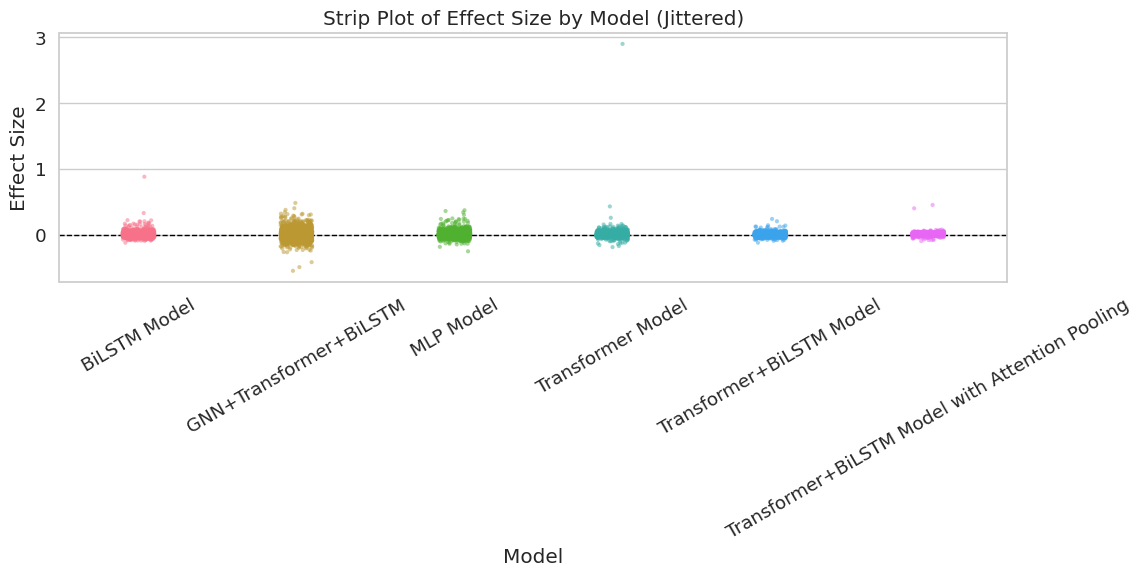

In [82]:
plt.figure(figsize=(12, 6))
sns.stripplot(data=df_sampled, x="Model", y="Effect Size", jitter=True, alpha=0.5, size=3, palette="husl")
plt.axhline(0, color="black", linestyle="--", lw=1)
plt.title("Strip Plot of Effect Size by Model (Jittered)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


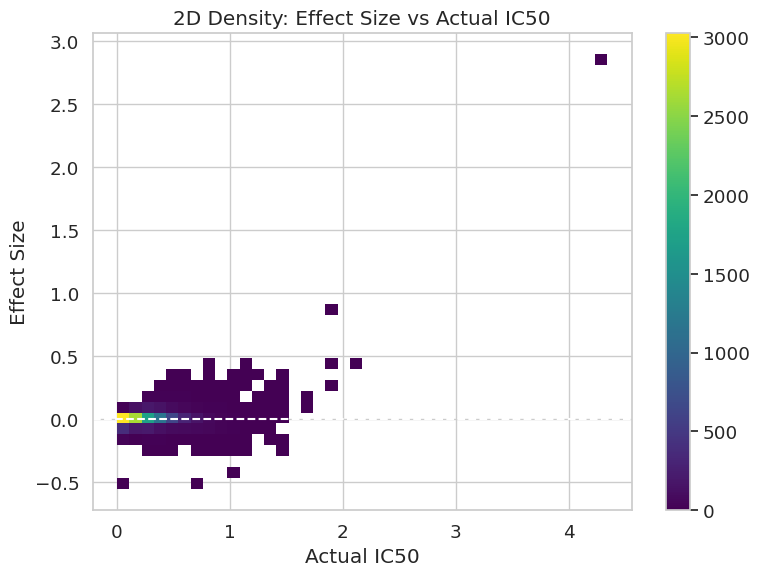

In [83]:
plt.figure(figsize=(8, 6))
sns.histplot(
    data=df_sampled, x="Actual IC50", y="Effect Size",
    bins=40, cbar=True, cmap="viridis"
)
plt.axhline(0, color="white", linestyle="--")
plt.title("2D Density: Effect Size vs Actual IC50")
plt.tight_layout()
plt.show()


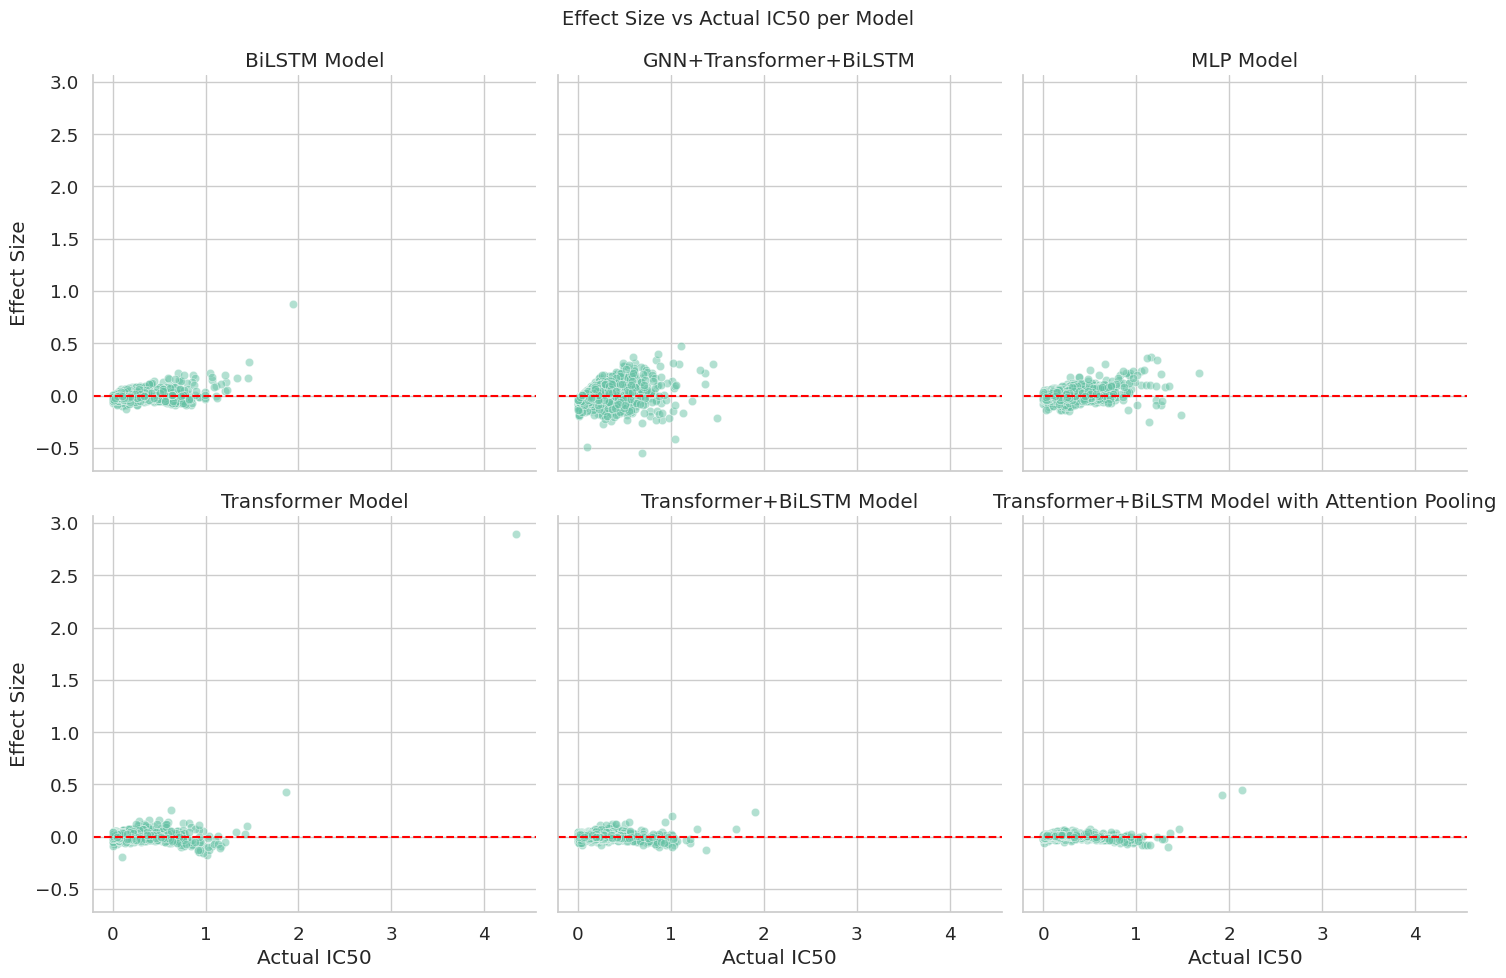

In [85]:
g = sns.FacetGrid(df_sampled, col="Model", col_wrap=3, height=3.5, sharex=True)
g.map_dataframe(sns.scatterplot, x="Actual IC50", y="Effect Size", alpha=0.5)
g.map(plt.axhline, y=0, ls="--", c="red")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.set_size_inches(15, 10)
g.fig.suptitle("Effect Size vs Actual IC50 per Model", fontsize=14)
plt.tight_layout()
plt.show()


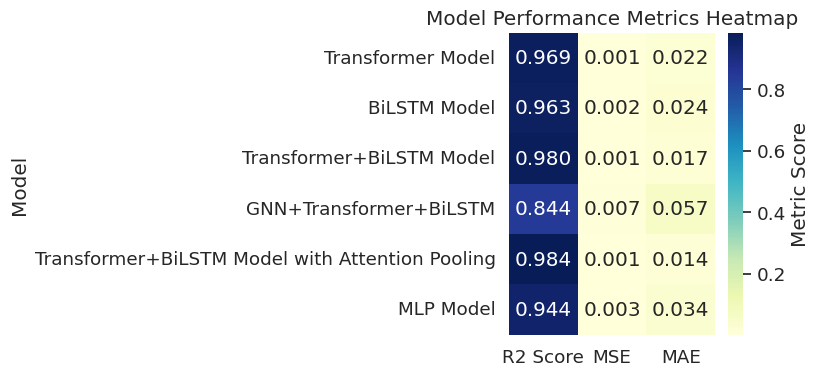

In [86]:
df_metrics = pd.DataFrame([
    {
        "Model": model_name,
        "R2 Score": res["R2"],
        "MSE": res["MSE"],
        "MAE": res["MAE"]
    }
    for model_name, res in results.items()
])

# Set model names as index
df_metrics.set_index("Model", inplace=True)

# 🎨 Plot heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(df_metrics, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={"label": "Metric Score"})
plt.title("Model Performance Metrics Heatmap")
plt.tight_layout()
plt.show()

In [93]:
from scipy.stats import ttest_rel

def compare_model_residuals(df_combined):
    print("\n🔬 Paired t-test based on per-sample residuals (Actual - Predicted):\n")

    models = df_combined['Model'].unique()
    model_preds = {}

    for model in models:
        subset = df_combined[df_combined['Model'] == model].sort_index()
        model_preds[model] = subset["Effect Size"].values  # Residuals = Actual - Pred

    for i in range(len(models)):
        for j in range(i+1, len(models)):
            m1, m2 = models[i], models[j]
            if len(model_preds[m1]) != len(model_preds[m2]):
                print(f"{m1} vs {m2}: skipped (unequal lengths)")
                continue

            t_stat, p_val = ttest_rel(model_preds[m1], model_preds[m2])
            print(f"{m1:60s} vs {m2:60s} | t = {t_stat:.4f}, p = {p_val:.4e}")

In [94]:
compare_model_residuals(df_combined)


🔬 Paired t-test based on per-sample residuals (Actual - Predicted):

Transformer Model                                            vs BiLSTM Model                                                 | t = 51.3388, p = 0.0000e+00
Transformer Model                                            vs Transformer+BiLSTM Model                                     | t = 70.5571, p = 0.0000e+00
Transformer Model                                            vs GNN+Transformer+BiLSTM                                       | t = 14.9269, p = 2.3242e-50
Transformer Model                                            vs Transformer+BiLSTM Model with Attention Pooling              | t = -88.9863, p = 0.0000e+00
Transformer Model                                            vs MLP Model                                                    | t = -44.0070, p = 0.0000e+00
BiLSTM Model                                                 vs Transformer+BiLSTM Model                                     | t = -8.9619, p = 3.2128e-1